# Deep Learning Lab - Image Classification
## From MLP to CNN to Transfer Learning

---

### Dataset: CIFAR-10

We are using CIFAR-10 as our dataset throughout this lab.
The reason for this choice is straightforward: the images are small (32x32 pixels, RGB),
the dataset is balanced with exactly the same number of samples per class,
and it covers 10 real-world categories which are airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

The total dataset size is 60,000 images. Since we want training to be reasonably fast,
we will sample 20 percent of it. We do this with stratified sampling, meaning we take
an equal percentage from each class so the balance is preserved.

The dataset is built into torchvision so we don't need to  manual download.

---

### Domain Investigation 

Before we do any transfer learning, we need to understand the gap between the dataset we have
and the dataset the pretrained model was trained on. This is not optional - it directly decides
how we should set up the fine-tuning.

We will use ResNet18 pretrained on ImageNet as our backbone.

ImageNet contains about 1.2 million images spread across 1000 categories.
The images are high resolution, typically 224x224 pixels.
The categories include all kinds of everyday objects, animals, vehicles, and scenes.

CIFAR-10 contains 60,000 small 32x32 images across 10 categories.
All 10 CIFAR-10 categories exist somewhere inside ImageNet's 1000 categories.

The conclusion from this comparison is that the domain gap is small.
Both datasets are natural images of real-world objects.
Low-level features like edges, corners, color gradients, and textures look the same
in both datasets. This means the early layers of ResNet, which detect these low-level features,
are directly useful for CIFAR-10 without any modification.

The only real difference is resolution. CIFAR-10 images are 32x32 while ResNet expects 224x224.
We handle this by resizing the images before feeding them to the pretrained model.

The practical implication is that transfer learning should work very well here.
Even freezing the entire backbone and only training the final classifier should give
decent results, because the features extracted by ResNet from CIFAR-10 images are meaningful.

---

## Cell 0 - Install Required Packages

In [1]:
# Run this cell first before anything else.
# It installs all the libraries we need.

import subprocess, sys

packages = [
    "torch",
    "torchvision",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "numpy",
    "tqdm",
    "ipywidgets",
]

for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f"installed: {pkg}")
    else:
        print(f"failed:    {pkg}")
        print(result.stderr[:200])


installed: torch
installed: torchvision
installed: matplotlib
installed: seaborn
installed: scikit-learn
installed: numpy
installed: tqdm
installed: ipywidgets


## Imports and Device Setup

In [2]:
import json, time, copy, random, warnings, sys
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, f1_score
)

# We fix all random seeds at the start so that every time you run this notebook
# you get the same results. This makes debugging and comparing experiments easier.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# We use GPU if available, otherwise fall back to CPU.
# The code is written so that it works on both without any changes.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {DEVICE}")
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"Python      : {sys.version.split()[0]}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")

Device      : cuda
PyTorch     : 2.7.1+cu118
Torchvision : 0.22.1+cu118
Python      : 3.11.9
GPU         : Quadro M1000M


---
## Data Loading and the Lazy Loading Concept

### What is Lazy Loading and Why Do We Need It

When you work with image datasets, especially large ones, you cannot simply load all the images
into memory at once. A dataset of 60,000 images at 224x224 resolution would require several
gigabytes of RAM just to store, and real-world datasets can have millions of images.

The solution is lazy loading. Instead of reading all the image files at startup,
we only read each image from disk at the moment we actually need it during training.

PyTorch handles this through the DataLoader class. When you create a DataLoader,
it does not read any images. It just knows where they are.
Then during the training loop, when you call next() on the iterator,
it reads exactly one batch worth of images from disk, processes them, and gives them to you.
After that batch is done, those images are discarded from memory and the next batch is read.

This way your memory usage stays constant regardless of how large the dataset is.
The torchvision.datasets.CIFAR10 class combined with DataLoader implements this automatically.
For datasets stored as raw image files on disk, torchvision.datasets.ImageFolder does the same thing.

### Transforms

We define two sets of transforms. One for the MLP and CNN which work on 32x32 images,
and one for the pretrained ResNet which requires 224x224 input matching what it was trained on.

For training we add light augmentation (horizontal flip and random crop).
For validation we never augment because we want a stable, unmodified evaluation.

In [3]:
# Global configuration values used throughout the notebook
SAMPLE_FRACTION  = 0.20   # use 20% of CIFAR-10
BATCH_SIZE_BASIC = 64     # batch size for MLP and CNN because it 32*32
BATCH_SIZE_PT    = 32     # batch size for pretrained models because it 224*224
NUM_CLASSES      = 10
NUM_WORKERS      = 2      # how many CPU threads to use for loading data in parallel
EPOCHS_SIMPLE    = 15     # epochs for MLP and CNN
EPOCHS_TL        = 10     # epochs for transfer learning scenarios

CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

# Transforms for MLP and CNN.
# We normalize using the channel-wise mean and standard deviation
# computed from the CIFAR-10 training set. Normalization helps
# gradient-based optimization converge faster.
transform_train_basic = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std =[0.2470, 0.2435, 0.2616])
])

transform_val_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std =[0.2470, 0.2435, 0.2616])
])

# Transforms for the pretrained ResNet.
# Two important things here:
# First, we resize to 224x224 because ResNet was  trained on that size.
# Second, we use ImageNet normalization statistics, not CIFAR-10 statistics,
# because the pretrained weights expect inputs normalized the same way
# as the data they were originally trained on.
transform_train_pt = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

transform_val_pt = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# Download CIFAR-10 into ./data/
# We create four dataset objects pointing to the same downloaded files
# but with different transforms applied.
full_train_basic = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True,  transform=transform_train_basic)
full_val_basic   = torchvision.datasets.CIFAR10(root="./data", train=False, download=False, transform=transform_val_basic)
full_train_pt    = torchvision.datasets.CIFAR10(root="./data", train=True,  download=False, transform=transform_train_pt)
full_val_pt      = torchvision.datasets.CIFAR10(root="./data", train=False, download=False, transform=transform_val_pt)

print(f"Full train size : {len(full_train_basic):,}")
print(f"Full val size   : {len(full_val_basic):,}")

Full train size : 50,000
Full val size   : 10,000


In [4]:
# Stratified sampling.
#
# We want 20 percent of the data. A naive approach would be to take
# the first 20 percent of samples, but that risks taking mostly
# one or two classes depending on how the data is ordered.
#
# Stratified sampling means we take 20 percent from each class separately.
# The result is a sample that has the same class proportions as the original dataset.
# This is important because a class imbalance would bias training and
# make the evaluation metrics misleading.

def stratified_sample(dataset, fraction, seed=42):
    rng     = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    indices = []
    for cls in range(NUM_CLASSES):
        cls_idx  = np.where(targets == cls)[0]
        n_sample = max(1, int(len(cls_idx) * fraction))
        sampled  = rng.choice(cls_idx, n_sample, replace=False)
        indices.extend(sampled.tolist())
    rng.shuffle(indices)
    return indices

train_idx = stratified_sample(full_train_basic, SAMPLE_FRACTION)
val_idx   = stratified_sample(full_val_basic,   SAMPLE_FRACTION)

# Print the class distribution to confirm the balance was preserved
sample_targets = np.array(full_train_basic.targets)[train_idx]
counts = np.bincount(sample_targets)
print("Samples per class in the training subset:")
for cls, cnt in zip(CLASSES, counts):
    print(f"  {cls:<14}: {cnt:,}")
print(f"\nTotal training samples   : {len(train_idx):,}")
print(f"Total validation samples : {len(val_idx):,}")

Samples per class in the training subset:
  airplane      : 1,000
  automobile    : 1,000
  bird          : 1,000
  cat           : 1,000
  deer          : 1,000
  dog           : 1,000
  frog          : 1,000
  horse         : 1,000
  ship          : 1,000
  truck         : 1,000

Total training samples   : 10,000
Total validation samples : 2,000


In [5]:
# Subset wraps the full dataset but only exposes the sampled indices.
train_subset_basic = Subset(full_train_basic, train_idx)
val_subset_basic   = Subset(full_val_basic,   val_idx)
train_subset_pt    = Subset(full_train_pt,    train_idx)
val_subset_pt      = Subset(full_val_pt,      val_idx)

# DataLoader is where lazy loading actually happens.
# while the GPU is processing the previous batch. This overlap hides
# the disk read latency and keeps the GPU busy.
# pin_memory=True moves data to page-locked memory which speeds up
# the transfer from CPU to GPU.
pin = (DEVICE.type == "cuda")

train_loader_basic = DataLoader(train_subset_basic, batch_size=BATCH_SIZE_BASIC, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=pin)
val_loader_basic   = DataLoader(val_subset_basic,   batch_size=BATCH_SIZE_BASIC, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
train_loader_pt    = DataLoader(train_subset_pt,    batch_size=BATCH_SIZE_PT,    shuffle=True,  num_workers=NUM_WORKERS, pin_memory=pin)
val_loader_pt      = DataLoader(val_subset_pt,      batch_size=BATCH_SIZE_PT,    shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)

print(f"Basic loaders    -> train: {len(train_loader_basic)} batches | val: {len(val_loader_basic)} batches")
print(f"Pretrained loaders -> train: {len(train_loader_pt)} batches | val: {len(val_loader_pt)} batches")
print("DataLoaders are ready. Images will be loaded batch by batch during training.")

Basic loaders    -> train: 157 batches | val: 32 batches
Pretrained loaders -> train: 313 batches | val: 63 batches
DataLoaders are ready. Images will be loaded batch by batch during training.


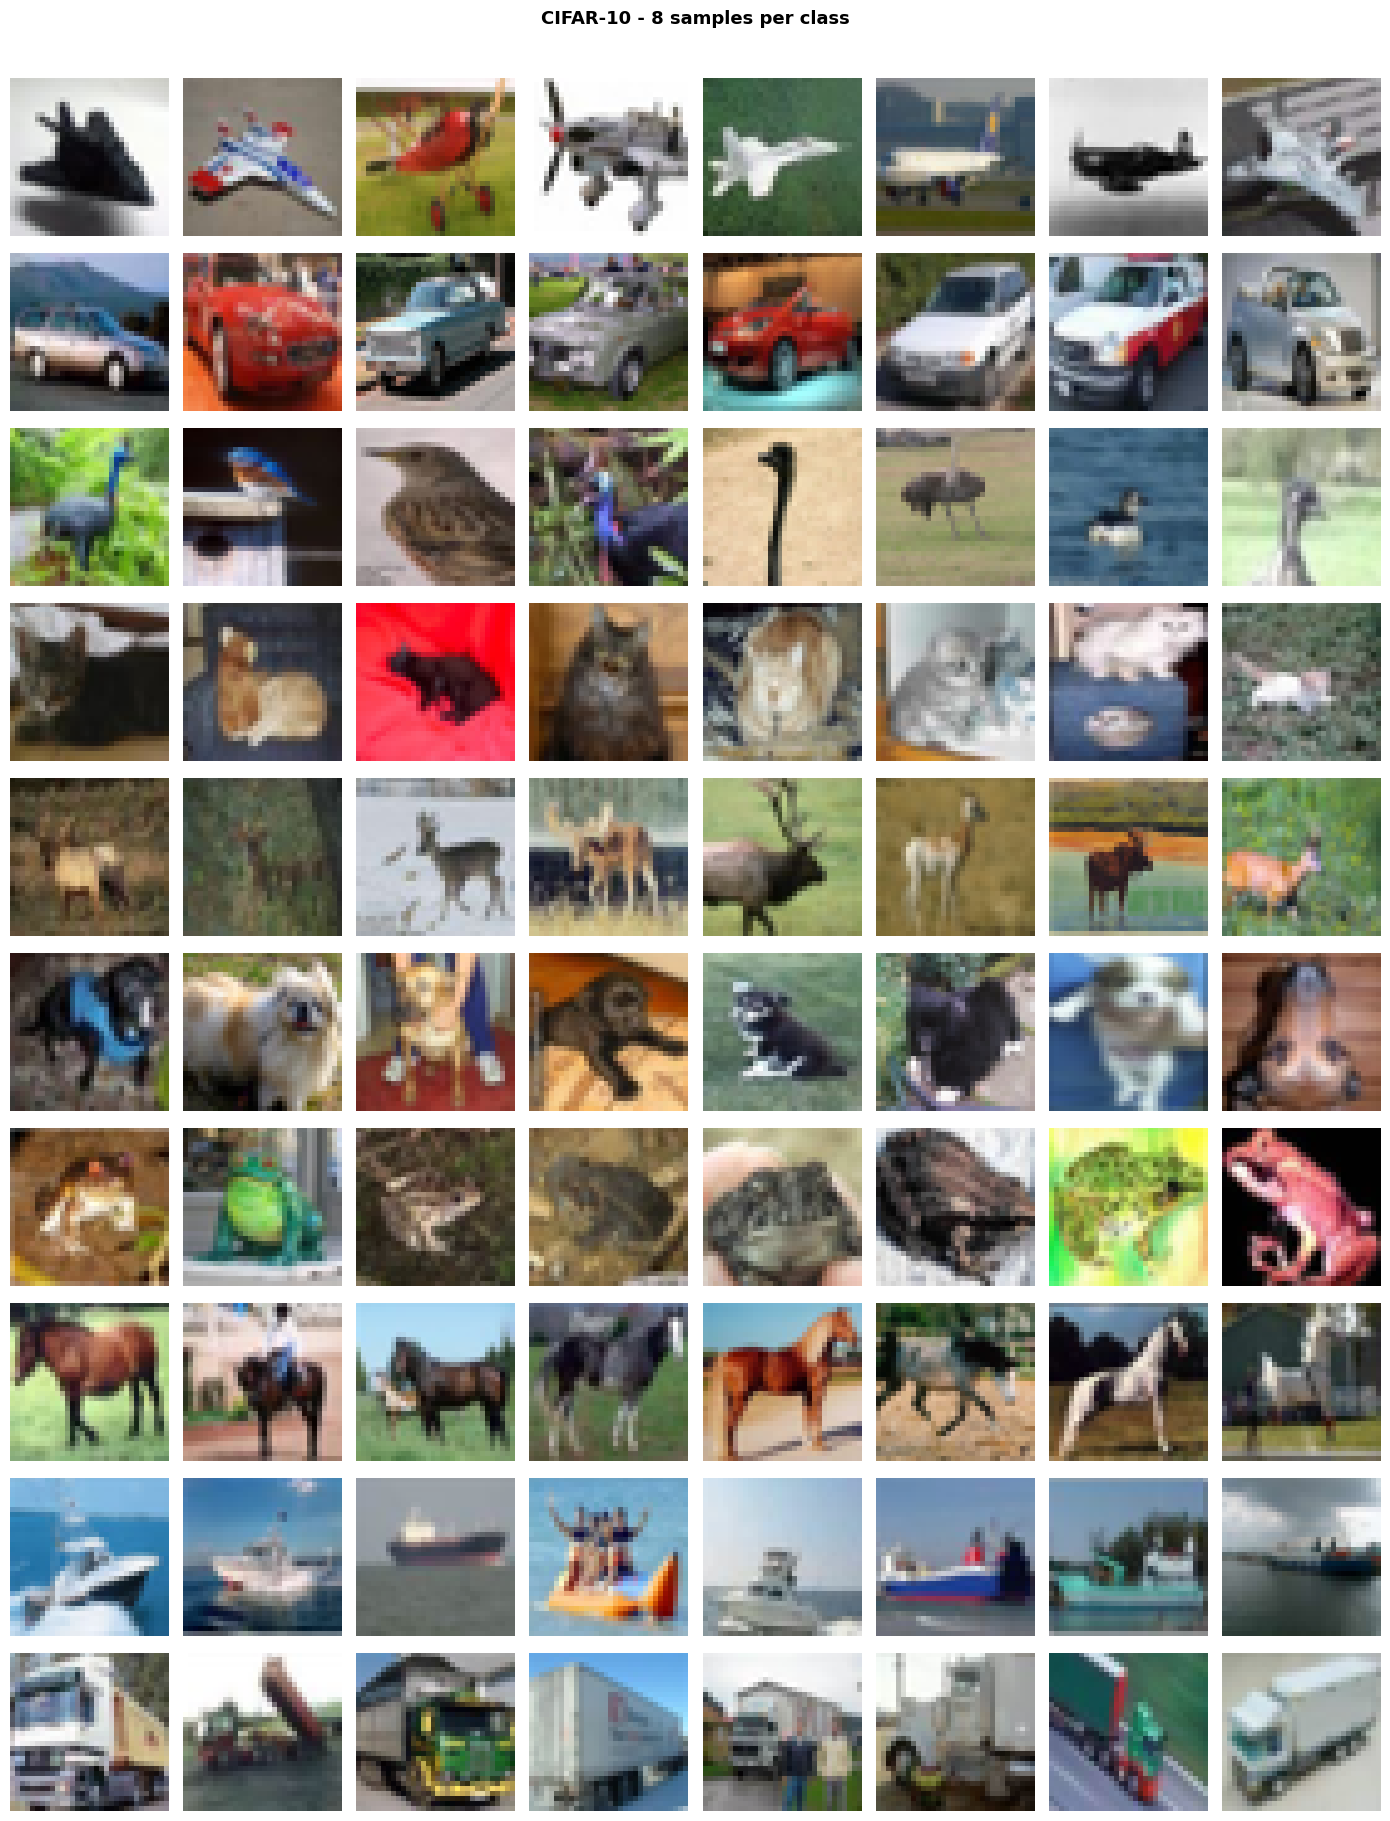

All classes are visible. The images are small and somewhat blurry at this zoom level,
which is expected for 32x32 resolution images. This is part of what makes
CIFAR-10 a challenging benchmark despite being a small dataset.


In [6]:
# Visualize a few samples to confirm the data looks correct.
# because normalization changes the pixel values and the image

raw_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=False, transform=transforms.ToTensor())

fig, axes = plt.subplots(10, 8, figsize=(14, 18))
class_counter = {c: 0 for c in range(10)}

for img, label in raw_dataset:
    c = label
    if class_counter[c] < 8:
        ax = axes[c][class_counter[c]]
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.axis("off")
        if class_counter[c] == 0:
            ax.set_ylabel(CLASSES[c], rotation=0, labelpad=55,
                          fontsize=10, fontweight="bold", va="center")
        class_counter[c] += 1
    if all(v == 8 for v in class_counter.values()):
        break

plt.suptitle("CIFAR-10 - 8 samples per class", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("All classes are visible. The images are small and somewhat blurry at this zoom level,")
print("which is expected for 32x32 resolution images. This is part of what makes")
print("CIFAR-10 a challenging benchmark despite being a small dataset.")

---
## Training and Evaluation Utilities

These functions are used by every model in this notebook.
Writing them once and reusing them prevents inconsistencies
when comparing results across models.

In [7]:
def train_one_epoch(model, loader, optimizer, criterion):
    # Set the model to training mode.
    # This activates BatchNorm statistics updates and enables Dropout.
    # Without this, BatchNorm would use its stored running statistics
    # and Dropout would be disabled, which is not what we want during training.
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        # Zero out gradients from the previous iteration.
        # PyTorch accumulates gradients by default, so we must clear them
        # before each new forward pass.
        optimizer.zero_grad()

        out  = model(imgs)
        loss = criterion(out, labels)

        # Backpropagation computes the gradient of the loss
        # with respect to every parameter that has requires_grad=True.
        loss.backward()

        # The optimizer uses the gradients to update the parameters.
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    # Set the model to evaluation mode.
    # This freezes BatchNorm running stats and disables Dropout.
    # The decorator @torch.no_grad() also disables gradient tracking,
    # which saves memory and speeds up the forward pass.
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = out.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


def run_training(model, train_loader, val_loader,
                 optimizer, criterion, scheduler=None,
                 epochs=10, model_name="model"):
    model.to(DEVICE)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_state   = None
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc       = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion)

        if scheduler:
            scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)

        is_best = vl_acc > best_val_acc
        if is_best:
            best_val_acc = vl_acc
            # We deep-copy the state dict so that subsequent training
            # does not overwrite this checkpoint in memory.
            best_state = copy.deepcopy(model.state_dict())

        marker = " <- best so far" if is_best else ""
        print(f"  Epoch {epoch:3d}/{epochs}"
              f"  |  Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:6.2f}%"
              f"  |  Val Loss: {vl_loss:.4f}  Acc: {vl_acc*100:6.2f}%"
              f"{marker}")

    elapsed = time.time() - t0
    # Restore the weights from the best validation epoch.
    # This is a simple form of early stopping - we do not stop early
    # but we do return the best checkpoint rather than the last one.
    model.load_state_dict(best_state)
    print(f"\n  Training time : {elapsed:.1f}s")
    print(f"  Best Val Acc  : {best_val_acc*100:.2f}%")
    history["best_val_acc"] = best_val_acc
    history["model_name"]   = model_name
    return history


def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history["train_loss"]) + 1)

    ax1.plot(epochs, history["train_loss"], "b-o", label="Train Loss", ms=5, lw=2)
    ax1.plot(epochs, history["val_loss"],   "r-o", label="Val Loss",   ms=5, lw=2)
    ax1.set_title("Loss", fontsize=13, fontweight="bold")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, [a*100 for a in history["train_acc"]], "b-o", label="Train Acc", ms=5, lw=2)
    ax2.plot(epochs, [a*100 for a in history["val_acc"]],   "r-o", label="Val Acc",   ms=5, lw=2)
    ax2.set_title("Accuracy", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_confusion(preds, labels, title=""):
    cm = confusion_matrix(labels, preds, normalize="true")
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, vmin=0, vmax=1)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True",      fontsize=12)
    ax.set_title(f"Confusion Matrix - {title}", fontsize=13, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def print_metrics(preds, labels, model_name=""):
    acc = accuracy_score(labels, preds)
    rec = recall_score(labels, preds, average="macro")
    f1  = f1_score(labels,     preds, average="macro")
    print(f"\n{'='*60}")
    print(f"  {model_name} - Final Evaluation")
    print(f"{'='*60}")
    print(f"  Accuracy      : {acc*100:.2f}%")
    print(f"  Macro Recall  : {rec*100:.2f}%")
    print(f"  Macro F1      : {f1*100:.2f}%")
    print(f"\n{classification_report(labels, preds, target_names=CLASSES)}")
    return {"accuracy": acc, "macro_recall": rec, "macro_f1": f1}


def get_first_conv_filters(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            return m.weight.detach().cpu().clone()

def plot_filters(filters, title, n=64, ncols=8):
    n     = min(n, filters.shape[0])
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.7, nrows * 1.7))
    for i, ax in enumerate(axes.flat):
        if i < n:
            f     = filters[i]
            f_norm = (f - f.min()) / (f.max() - f.min() + 1e-8)
            ax.imshow(f_norm.permute(1, 2, 0).numpy(), interpolation="nearest")
            ax.set_title(f"F{i}", fontsize=5)
        ax.axis("off")
    plt.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

print("All utility functions defined.")

All utility functions defined.


---
## Part 1 - MLP (Multi-Layer Perceptron)

### The baseline and why we start here

Before building a proper image classifier, we deliberately start with the wrong architecture.
An MLP takes a flat vector as input. When we feed it an image, the first thing we do is
flatten the 3x32x32 tensor into a single vector of 3072 numbers.

This flattening operation throws away all spatial information.
The MLP has no idea that pixel at position (5, 6) is physically next to pixel at (5, 7).
From the MLP's perspective, those two pixels could be on opposite ends of the image.
It treats every pixel as an independent feature with no relationship to its neighbors.

This is the fundamental limitation. Shape recognition, texture patterns, and object boundaries
all depend on the spatial arrangement of pixels. An MLP cannot learn these things
because it does not know the arrangement exists.

We start here so we have a concrete baseline number. When CNN outperforms MLP,
we understand exactly why - it is not because CNN has more parameters or trains longer,
it is because CNN uses the right inductive bias for images.

### Architecture decisions

We use three hidden layers of size 1024, 512, and 256.
BatchNorm1d is added after each linear layer because it normalizes the activations
across the batch, which reduces internal covariate shift and allows us to use
higher learning rates without the training becoming unstable.
Dropout at 0.4 randomly zeros out 40 percent of activations during each forward pass,
which forces the network to not rely on any single path and acts as regularization.
The output layer has 10 neurons, one per class, with no activation because
CrossEntropyLoss applies softmax internally.

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim=3*32*32, hidden_dims=[1024, 512, 256], num_classes=10, dropout=0.4):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # This is where all spatial information is discarded.
        # A 32x32 RGB image becomes a list of 3072 numbers.
        # The network has no way to recover the original spatial layout.
        x = x.view(x.size(0), -1)
        return self.net(x)


mlp_check = MLP()
total_mlp  = sum(p.numel() for p in mlp_check.parameters())
print("MLP structure:")
print(mlp_check)
print(f"\nTotal parameters: {total_mlp:,}")

# Quick forward pass to confirm the shapes are correct
with torch.no_grad():
    dummy = torch.randn(4, 3, 32, 32)
    out   = mlp_check(dummy)
print(f"\nInput shape  : {dummy.shape}")
print(f"Output shape : {out.shape}  - should be (4, 10)")

MLP structure:
MLP(
  (net): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=256, out_features=10, bias=True)
  )
)

Total parameters: 3,809,034

Input shape  : torch.Size([4, 3, 32, 32])
Output shape : torch.Size([4, 10])  - should be (4, 10)


In [9]:
# Training setup for MLP.
#
# We use CrossEntropyLoss which combines log-softmax and negative log-likelihood
# into a single numerically stable operation. This is the standard choice
# for multi-class classification in PyTorch.
#
# Adam handles the adaptive learning rate automatically, which is convenient
# when we do not want to spend time tuning a fixed learning rate schedule.
# weight_decay adds L2 regularization to the loss, penalizing large weights
# and reducing overfitting.
#
# CosineAnnealingLR smoothly reduces the learning rate from its initial value
# down to nearly zero following a cosine curve. This tends to give better
# final performance than a fixed learning rate because the model can take
# larger steps early in training and refine carefully toward the end.

mlp_model = MLP().to(DEVICE)
mlp_crit  = nn.CrossEntropyLoss()
mlp_optim = optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
mlp_sched = optim.lr_scheduler.CosineAnnealingLR(mlp_optim, T_max=EPOCHS_SIMPLE)

print("Training MLP...")
print()
mlp_history = run_training(
    mlp_model, train_loader_basic, val_loader_basic,
    mlp_optim, mlp_crit, mlp_sched,
    epochs=EPOCHS_SIMPLE, model_name="MLP"
)

Training MLP...

  Epoch   1/15  |  Train Loss: 2.0630  Acc:  24.31%  |  Val Loss: 1.8448  Acc:  33.40% <- best so far
  Epoch   2/15  |  Train Loss: 1.9177  Acc:  29.94%  |  Val Loss: 1.7662  Acc:  36.30% <- best so far
  Epoch   3/15  |  Train Loss: 1.8507  Acc:  31.92%  |  Val Loss: 1.6944  Acc:  38.60% <- best so far
  Epoch   4/15  |  Train Loss: 1.8071  Acc:  34.21%  |  Val Loss: 1.6521  Acc:  40.35% <- best so far
  Epoch   5/15  |  Train Loss: 1.7815  Acc:  34.61%  |  Val Loss: 1.6513  Acc:  40.65% <- best so far
  Epoch   6/15  |  Train Loss: 1.7583  Acc:  35.93%  |  Val Loss: 1.5928  Acc:  42.55% <- best so far
  Epoch   7/15  |  Train Loss: 1.7270  Acc:  37.15%  |  Val Loss: 1.5670  Acc:  44.20% <- best so far
  Epoch   8/15  |  Train Loss: 1.7092  Acc:  37.71%  |  Val Loss: 1.5549  Acc:  43.95%
  Epoch   9/15  |  Train Loss: 1.6958  Acc:  38.01%  |  Val Loss: 1.5269  Acc:  44.55% <- best so far
  Epoch  10/15  |  Train Loss: 1.6668  Acc:  39.57%  |  Val Loss: 1.5073  Acc:  

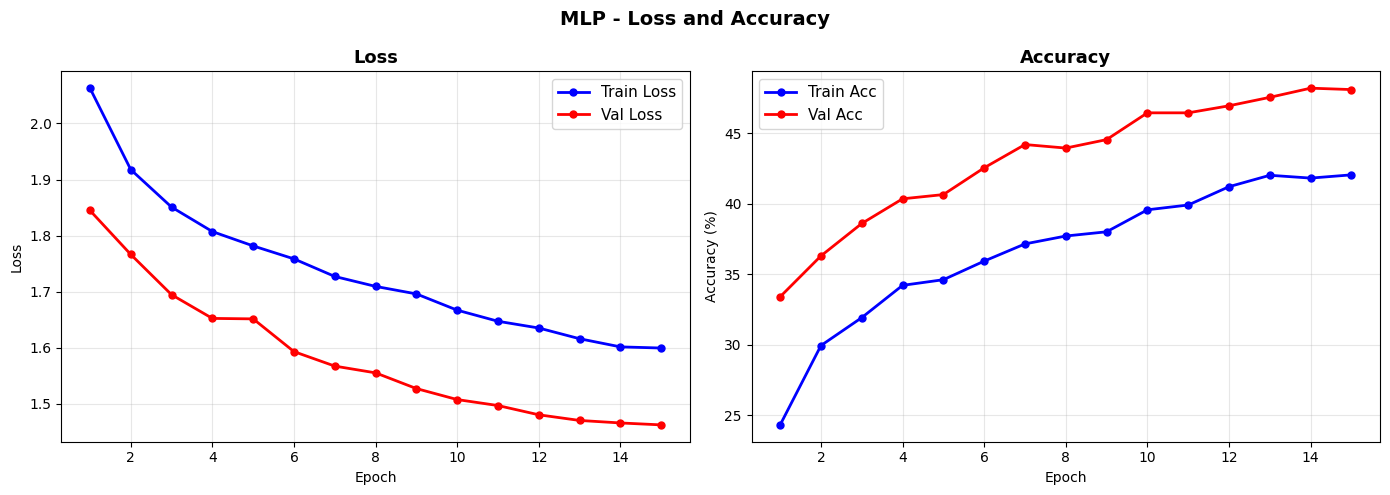


  MLP - Final Evaluation
  Accuracy      : 48.20%
  Macro Recall  : 48.20%
  Macro F1      : 47.33%

              precision    recall  f1-score   support

    airplane       0.52      0.60      0.56       200
  automobile       0.58      0.56      0.57       200
        bird       0.40      0.34      0.37       200
         cat       0.37      0.28      0.32       200
        deer       0.43      0.28      0.34       200
         dog       0.45      0.34      0.39       200
        frog       0.44      0.59      0.51       200
       horse       0.48      0.58      0.52       200
        ship       0.59      0.60      0.60       200
       truck       0.50      0.63      0.56       200

    accuracy                           0.48      2000
   macro avg       0.48      0.48      0.47      2000
weighted avg       0.48      0.48      0.47      2000



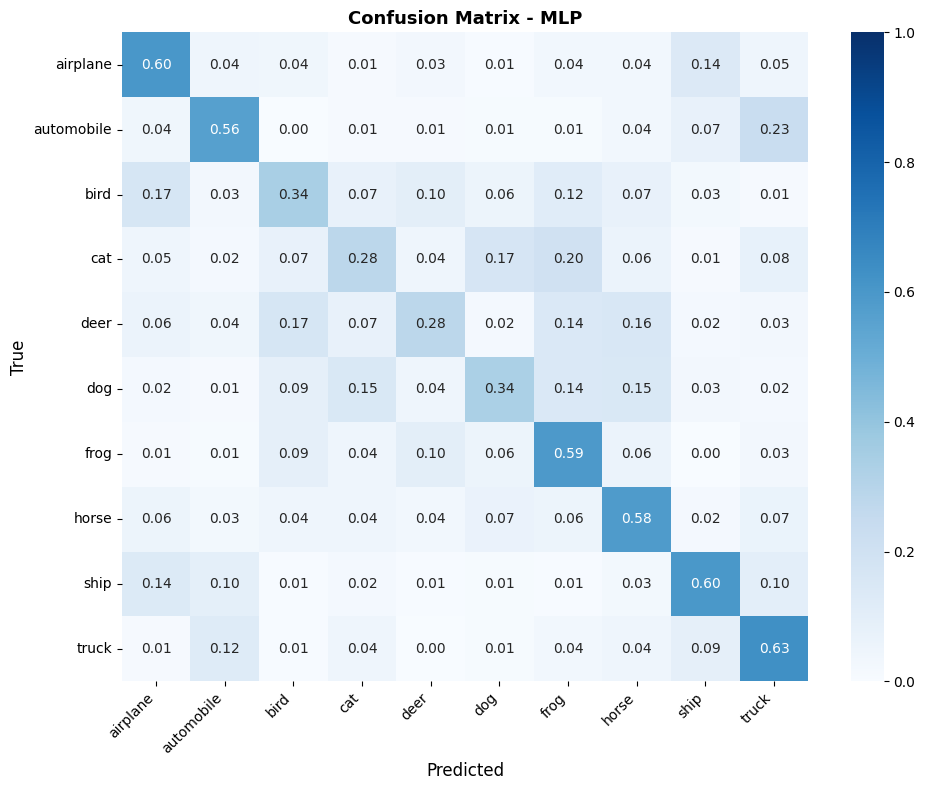

In [10]:
plot_history(mlp_history, "MLP - Loss and Accuracy")

_, _, mlp_preds, mlp_labels = evaluate(mlp_model, val_loader_basic, mlp_crit)
mlp_metrics = print_metrics(mlp_preds, mlp_labels, "MLP")
plot_confusion(mlp_preds, mlp_labels, "MLP")

### MLP Results - What the Numbers Are Telling Us

The validation accuracy should land somewhere around 45 to 55 percent.
This is noticeably above random chance which would be 10 percent for a 10-class problem,
so the model did learn something. But it is far from useful.

Looking at the loss curves, you will likely see the training loss continue dropping
while the validation loss levels off or starts rising. This is a textbook overfitting pattern.
The model is memorizing specific pixel patterns from the training set that do not generalize
to unseen images.

The confusion matrix usually shows the worst performance on cat, dog, and bird.
These three classes share similar color distributions and without any spatial understanding,
the model cannot distinguish a cat face from a dog face - they both look like a similar
blob of brown and white pixels when you strip away the spatial arrangement.

Classes like ship and automobile tend to do a bit better because they have more distinctive
color signatures. Ships are often against blue backgrounds and automobiles often appear
on grey road surfaces. The MLP can pick up on these color biases even without understanding shape.

The fundamental lesson here is that raw pixel values without spatial context are
not a good input representation for image classification. The architecture
does not match the structure of the data.

---
## Part 2 - CNN (Convolutional Neural Network)

### Why CNN is the right tool for images

A convolutional layer does not look at each pixel in isolation.
Instead it slides a small filter (we use 3x3) across the entire image,
computing a dot product at each position. This means the filter looks at
a pixel together with its immediate neighbors, which is exactly where
meaningful image structure exists.

The same filter is used at every position in the image. This is called weight sharing.
A filter that detects a horizontal edge will detect that edge whether it appears
at the top left or the bottom right of the image. This gives CNNs translation equivariance
for free, without needing extra examples showing the same object at different positions.

Because each filter produces an output for every spatial position, the total number
of parameters is much smaller than a fully connected layer covering the same area.
A 3x3 filter with 3 input channels and 64 output channels has only 3x3x3x64 = 1,728 parameters.
An equivalent fully connected layer would need far more.

Stacking convolutional layers creates a hierarchy. The first layer learns to detect
simple patterns like edges at different orientations and color transitions.
The second layer sees the output of the first layer and learns to detect combinations
of edges, which correspond to corners and simple shapes.
Deeper layers detect progressively more complex and abstract features until eventually
the deepest layers are activating strongly for complete objects or object parts.

### The golden rules applied in this architecture

We use 3x3 filters throughout because they are computationally efficient and
two stacked 3x3 convolutions cover the same receptive field as one 5x5 convolution
but with fewer parameters and an extra nonlinearity in between.

We double the number of channels after each pooling operation.
As spatial dimensions shrink by a factor of 2 in each direction (losing 75% of positions),
we compensate by increasing the number of feature maps so the total information
capacity of the representation does not collapse too quickly.

BatchNorm2d is applied after every convolutional layer.
It normalizes each feature map across the batch dimension which keeps
activation magnitudes in a healthy range and allows larger learning rates.

Global Average Pooling replaces the traditional Flatten followed by a large fully connected layer.
After the three conv blocks, the feature maps are 4x4 spatially with 256 channels.
Flatten would give us 256x4x4 = 4096 inputs to the classifier.
GAP instead takes the spatial average of each channel, giving us just 256 numbers.
This dramatically reduces the parameter count of the classifier and acts as regularization.

Kaiming initialization sets the initial weights to have the right scale for ReLU activations,
preventing the gradients from vanishing or exploding in the very first few iterations.

In [11]:
class ConvBlock(nn.Module):
    # A reusable building block: two conv layers followed by optional pooling.
    # Using two conv layers before pooling lets each block build richer features
    # before the spatial resolution is reduced.
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            # bias=False because BatchNorm that follows has its own learnable bias parameter.
            # Including both would be redundant.
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        # Spatial dimensions and channel counts through the network:
        # Input     : (B,   3, 32, 32)
        # Block 1   : (B,  64, 16, 16)
        # Block 2   : (B, 128,  8,  8)
        # Block 3   : (B, 256,  4,  4)
        # After GAP : (B, 256)
        self.features = nn.Sequential(
            ConvBlock(3,   64,  pool=True),
            ConvBlock(64,  128, pool=True),
            ConvBlock(128, 256, pool=True),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # Kaiming normal initialization for layers followed by ReLU.
                # It sets the variance of the initial weights to 2/fan_in,
                # which keeps the signal from shrinking through many ReLU layers.
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias,   0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


cnn_check = CNN()
total_cnn  = sum(p.numel() for p in cnn_check.parameters())
print(f"CNN total parameters  : {total_cnn:,}")
print(f"MLP total parameters  : {sum(p.numel() for p in MLP().parameters()):,}")
print()
print("The CNN has fewer parameters than the MLP yet will perform much better.")
print("This shows that the right inductive bias matters more than raw capacity.")

with torch.no_grad():
    dummy = torch.randn(4, 3, 32, 32)
    f = cnn_check.features(dummy)
    g = cnn_check.gap(f)
    o = cnn_check(dummy)
print(f"\nInput shape          : {dummy.shape}")
print(f"After feature blocks : {f.shape}")
print(f"After global avg pool: {g.shape}")
print(f"Output shape         : {o.shape}")

CNN total parameters  : 1,180,490
MLP total parameters  : 3,809,034

The CNN has fewer parameters than the MLP yet will perform much better.
This shows that the right inductive bias matters more than raw capacity.

Input shape          : torch.Size([4, 3, 32, 32])
After feature blocks : torch.Size([4, 256, 4, 4])
After global avg pool: torch.Size([4, 256, 1, 1])
Output shape         : torch.Size([4, 10])


Captured 64 filters of size 3x3 before training.



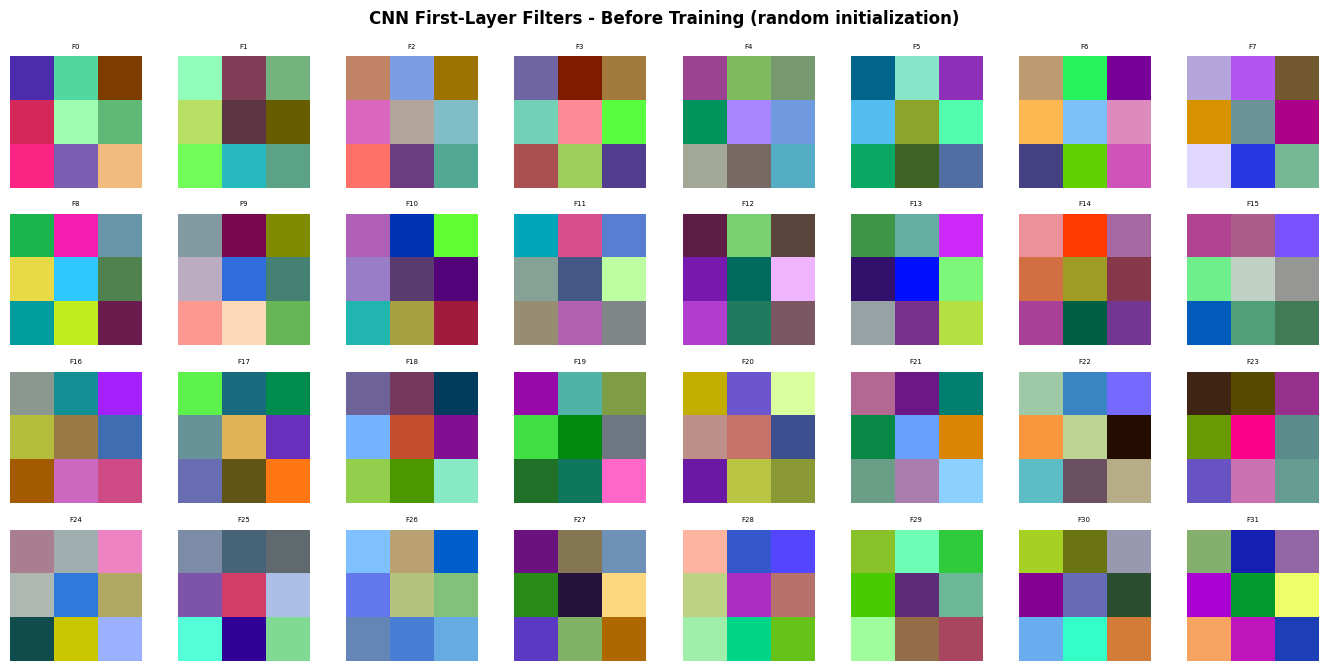

These filters are random noise. The network cannot detect anything meaningful yet.
Each filter responds to different random combinations of pixel values in a 3x3 patch.


In [12]:
# Capture the first-layer filters before any training happens.
# At this point the weights come purely from Kaiming initialization -
# small random values with no learned structure.
# We save them now to compare against the trained filters later.

cnn_model          = CNN().to(DEVICE)
filters_cnn_before = get_first_conv_filters(cnn_model)

print(f"Captured {filters_cnn_before.shape[0]} filters of size {filters_cnn_before.shape[2]}x{filters_cnn_before.shape[3]} before training.")
print()
plot_filters(filters_cnn_before, "CNN First-Layer Filters - Before Training (random initialization)", n=32, ncols=8)

print("These filters are random noise. The network cannot detect anything meaningful yet.")
print("Each filter responds to different random combinations of pixel values in a 3x3 patch.")

In [13]:
# We add label smoothing (0.1) to the loss function.
# Standard CrossEntropyLoss trains the model to output probability 1.0
# for the correct class and 0.0 for all others.
# Label smoothing instead targets 0.9 for the correct class and distributes
# the remaining 0.1 across all classes.
# This prevents the model from becoming overconfident and tends to improve
# generalization because the model learns a softer, more calibrated output distribution.

cnn_crit  = nn.CrossEntropyLoss(label_smoothing=0.1)
cnn_optim = optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
cnn_sched = optim.lr_scheduler.CosineAnnealingLR(cnn_optim, T_max=EPOCHS_SIMPLE)

print("Training CNN...")
print()
cnn_history = run_training(
    cnn_model, train_loader_basic, val_loader_basic,
    cnn_optim, cnn_crit, cnn_sched,
    epochs=EPOCHS_SIMPLE, model_name="CNN"
)

Training CNN...

  Epoch   1/15  |  Train Loss: 2.0758  Acc:  26.95%  |  Val Loss: 1.8268  Acc:  34.50% <- best so far
  Epoch   2/15  |  Train Loss: 1.8140  Acc:  37.28%  |  Val Loss: 1.7367  Acc:  43.40% <- best so far
  Epoch   3/15  |  Train Loss: 1.6642  Acc:  45.72%  |  Val Loss: 1.5470  Acc:  52.60% <- best so far
  Epoch   4/15  |  Train Loss: 1.5725  Acc:  50.69%  |  Val Loss: 1.5579  Acc:  52.00%
  Epoch   5/15  |  Train Loss: 1.4852  Acc:  55.55%  |  Val Loss: 1.3886  Acc:  59.25% <- best so far
  Epoch   6/15  |  Train Loss: 1.4254  Acc:  58.70%  |  Val Loss: 1.4188  Acc:  59.55% <- best so far
  Epoch   7/15  |  Train Loss: 1.3752  Acc:  60.91%  |  Val Loss: 1.4243  Acc:  59.20%
  Epoch   8/15  |  Train Loss: 1.3196  Acc:  63.85%  |  Val Loss: 1.3985  Acc:  60.00% <- best so far
  Epoch   9/15  |  Train Loss: 1.2659  Acc:  67.07%  |  Val Loss: 1.3114  Acc:  64.65% <- best so far
  Epoch  10/15  |  Train Loss: 1.2159  Acc:  69.59%  |  Val Loss: 1.2018  Acc:  69.45% <- best 

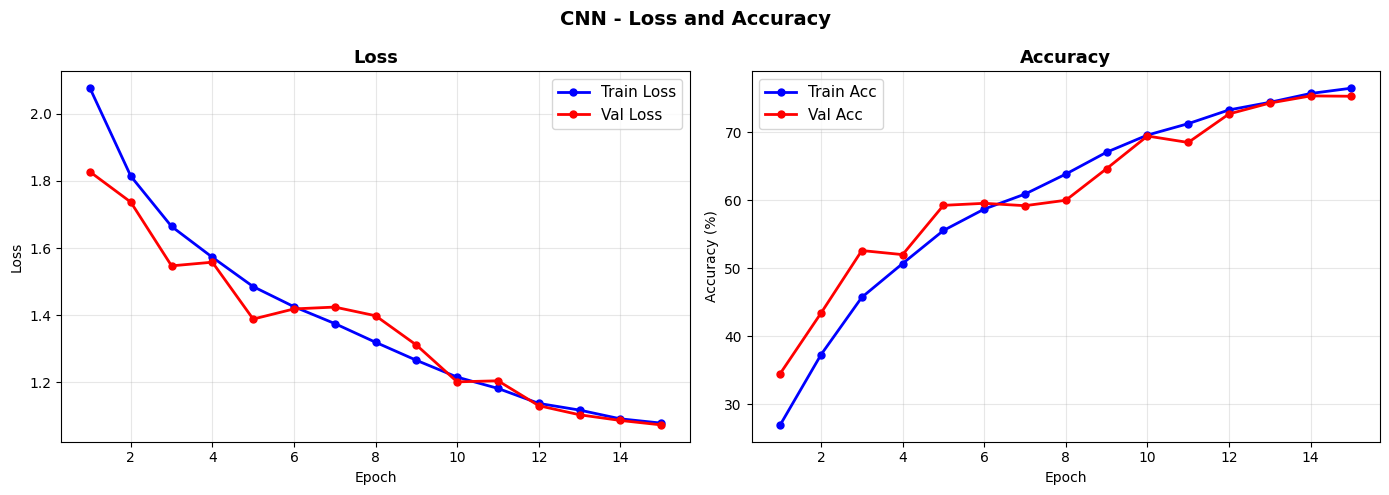


  CNN - Final Evaluation
  Accuracy      : 75.35%
  Macro Recall  : 75.35%
  Macro F1      : 74.97%

              precision    recall  f1-score   support

    airplane       0.80      0.83      0.81       200
  automobile       0.81      0.94      0.87       200
        bird       0.69      0.65      0.67       200
         cat       0.58      0.40      0.47       200
        deer       0.73      0.70      0.72       200
         dog       0.58      0.77      0.66       200
        frog       0.78      0.78      0.78       200
       horse       0.80      0.80      0.80       200
        ship       0.87      0.90      0.89       200
       truck       0.93      0.78      0.85       200

    accuracy                           0.75      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.75      0.75      0.75      2000



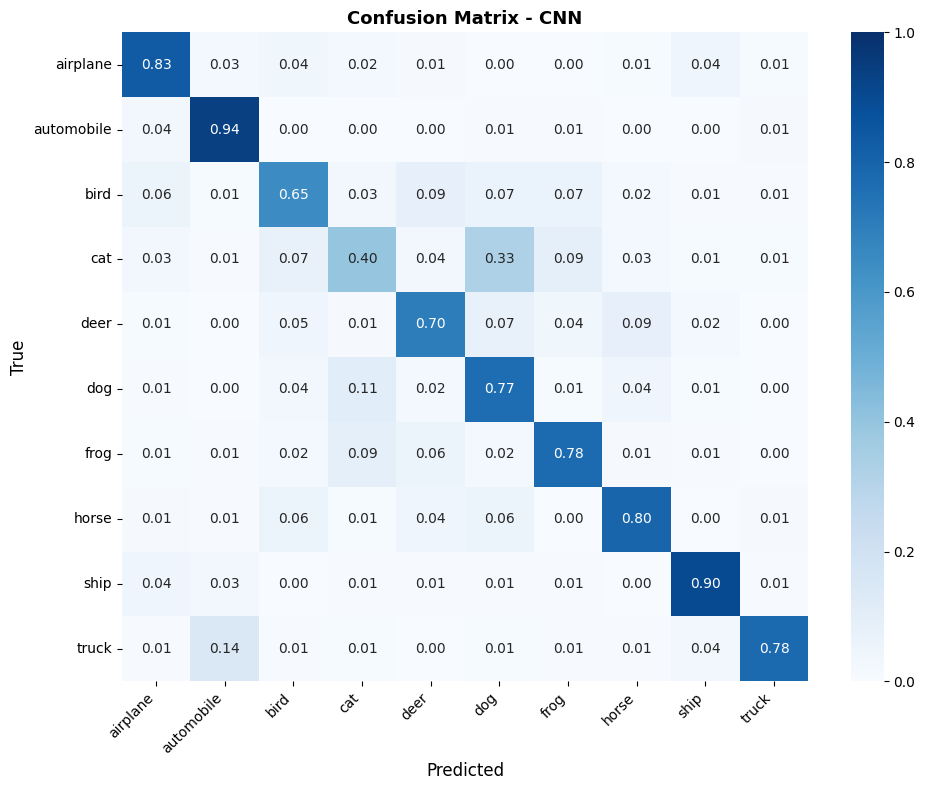

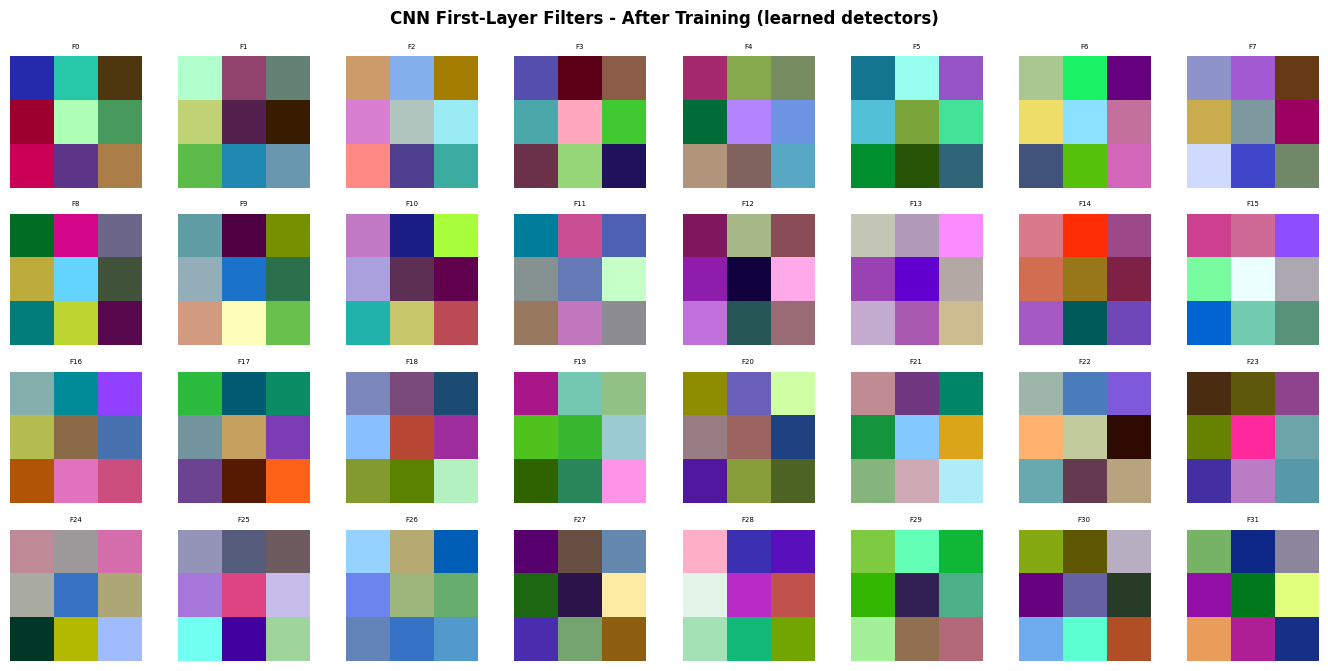

In [14]:
plot_history(cnn_history, "CNN - Loss and Accuracy")

_, _, cnn_preds, cnn_labels = evaluate(cnn_model, val_loader_basic, cnn_crit)
cnn_metrics = print_metrics(cnn_preds, cnn_labels, "CNN")
plot_confusion(cnn_preds, cnn_labels, "CNN")

# Capture the filters now that training is complete.
# The comparison between before and after is the most direct visualization
# of what the network actually learned.
filters_cnn_after = get_first_conv_filters(cnn_model)
plot_filters(filters_cnn_after, "CNN First-Layer Filters - After Training (learned detectors)", n=32, ncols=8)

### CNN Results - Interpreting the Improvement

The accuracy should be significantly higher than MLP, typically in the range of 70 to 78 percent.
This improvement came from no change to the data, no change to the optimizer,
and actually fewer parameters. The only change was the architecture.

The loss curves should show a much tighter gap between training and validation compared to MLP.
CNNs generalize better because weight sharing forces them to learn patterns
that work across the entire image rather than memorizing position-specific correlations.

Looking at the confusion matrix, you will notice that the previously disastrous cat and dog confusion
has improved, though these two classes remain the hardest to separate. This makes sense -
cats and dogs have similar shapes, similar color ranges, and similar sizes in these photos.
Even humans sometimes make mistakes on very small, blurry images of cats and dogs.

The filter visualization is the most interesting result here.
Before training you saw random noise. After training you should see clear structure:
some filters have a bright region on one side and a dark region on the other,
which is an edge detector. Some filters show a single color channel dominating strongly,
which is a color detector. Some show a bright center with darker surroundings,
which responds to blob-like features.

These patterns are not something we designed. The network discovered them on its own
because they are the most useful low-level features for distinguishing the 10 classes.
Interestingly, neuroscientists found the same types of filters in the primary visual cortex
of mammals long before deep learning existed. The math leads to the same solution
whether implemented in neurons or gradient descent.

---
## Part 3 - Transfer Learning with ResNet18

### The core idea

Training a deep network from scratch requires a lot of data and a lot of compute.
ResNet18 was trained on 1.2 million images for many days on expensive hardware.
Transfer learning lets us skip that cost by starting from those already-trained weights.

The pretrained ResNet has already learned to detect edges, textures, shapes,
and high-level semantic features from 1.2 million diverse images.
Instead of relearning all of this from our 12,000 training samples,
we start from where ResNet left off.

### What gets replaced and what gets kept

The final fully connected layer of ResNet18 outputs 1000 scores, one per ImageNet class.
We replace this layer with a new small MLP that outputs 10 scores for our classes.
The new layer has random weights and must be trained from scratch.

Everything else in the network already has meaningful weights from ImageNet training.
The question is how much of it we allow to update during our training.

### Three scenarios with increasing freedom

Scenario 3A freezes the entire backbone. Only our new classification head is trained.
The backbone acts as a fixed feature extractor. This is the right choice when your
dataset is very small and your domain is very similar to what the model was pretrained on.

Scenario 3B freezes the early layers (conv1, layer1, layer2) but allows
the later layers (layer3, layer4) to update along with the new head.
The reasoning is that early layers detect universal low-level features that are
identical across all natural image datasets. There is no point in relearning edges.
Later layers detect object-specific high-level features that may differ between
ImageNet and CIFAR-10, so we allow them to adapt.

Scenario 3C unfreezes everything. Every parameter in the network can be updated.
This gives maximum flexibility but also maximum risk of catastrophic forgetting,
which is when the new training data destroys the pretrained knowledge in early layers.
We mitigate this using a tiered learning rate strategy described below.

### Why differential learning rates matter

In fine-tuning, using the same learning rate for all layers is usually a mistake.
A high learning rate applied to pretrained early layers will wash away their
carefully learned universal features within the first few epochs.
A low learning rate applied to the new head will make it converge very slowly.

The solution is to give each group of layers its own learning rate.
Early pretrained layers get a very small rate (we use 5e-6 for the earliest layers).
The new head gets a much larger rate (we use 5e-4).
This way the head learns quickly while the backbone adapts gently.

In [15]:
def build_resnet18(freeze_mode="none"):
    # Load ResNet18 with the weights it had after ImageNet training.
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Replace the final classification layer.
    # We add dropout and an intermediate layer to give the head
    # a bit more capacity and regularization.
    in_features = model.fc.in_features  # this is 512 in ResNet18
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(256, NUM_CLASSES)
    )

    if freeze_mode == "all":
        # Freeze all layers except our new head.
        # Setting requires_grad=False means these parameters will not
        # accumulate gradients and will not be updated by the optimizer.
        for name, param in model.named_parameters():
            if not name.startswith("fc"):
                param.requires_grad = False

    elif freeze_mode == "early":
        # Freeze only the early layers.
        # conv1 and bn1 are the very first layer.
        # layer1 and layer2 handle low and mid-level features
        # like edges, corners, and simple texture patterns.
        for name, param in model.named_parameters():
            if any(name.startswith(p) for p in ["conv1", "bn1", "layer1", "layer2"]):
                param.requires_grad = False

    # Print a summary so we know exactly what is and is not training.
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = total - trainable
    print(f"  Freeze mode : {freeze_mode}")
    print(f"  Total params: {total:,}")
    print(f"  Trainable   : {trainable:,}  ({trainable/total*100:.1f}%)")
    print(f"  Frozen      : {frozen:,}  ({frozen/total*100:.1f}%)")
    return model

print("ResNet18 builder defined.")

ResNet18 builder defined.


### Scenario 3A - Train Only the Classification Head

In [16]:
# Scenario 3A: the backbone is completely frozen.
#
# This is the computationally cheapest option.
# We only have a few thousand parameters to optimize (our small FC head).
# Forward passes still go through the entire ResNet but gradients are
# only computed for the head layers, not the backbone.
#
# This works well here because CIFAR-10 and ImageNet are both natural images.
# The ResNet features extracted from CIFAR-10 images are highly relevant.
# We just need to learn how to map those features to our 10 specific classes.

print("Building ResNet18 - Scenario 3A (frozen backbone)")
print()
model_3a = build_resnet18(freeze_mode="all").to(DEVICE)

# We only pass the parameters that have requires_grad=True.
# If we accidentally included frozen parameters, the optimizer would
# track them unnecessarily and waste memory on zero gradients.
trainable_3a = [p for p in model_3a.parameters() if p.requires_grad]
optim_3a = optim.Adam(trainable_3a, lr=1e-3, weight_decay=1e-4)
crit_3a  = nn.CrossEntropyLoss()
sched_3a = optim.lr_scheduler.StepLR(optim_3a, step_size=4, gamma=0.5)

print()
print("Training 3A...")
print()
history_3a = run_training(
    model_3a, train_loader_pt, val_loader_pt,
    optim_3a, crit_3a, sched_3a,
    epochs=EPOCHS_TL, model_name="TL-3A (FC only)"
)

Building ResNet18 - Scenario 3A (frozen backbone)

  Freeze mode : all
  Total params: 11,310,410
  Trainable   : 133,898  (1.2%)
  Frozen      : 11,176,512  (98.8%)

Training 3A...

  Epoch   1/10  |  Train Loss: 1.1924  Acc:  58.47%  |  Val Loss: 0.7293  Acc:  74.55% <- best so far
  Epoch   2/10  |  Train Loss: 0.9273  Acc:  68.59%  |  Val Loss: 0.7099  Acc:  75.05% <- best so far
  Epoch   3/10  |  Train Loss: 0.8933  Acc:  69.33%  |  Val Loss: 0.7126  Acc:  73.75%
  Epoch   4/10  |  Train Loss: 0.8731  Acc:  70.01%  |  Val Loss: 0.6824  Acc:  75.80% <- best so far
  Epoch   5/10  |  Train Loss: 0.8122  Acc:  71.99%  |  Val Loss: 0.6154  Acc:  78.70% <- best so far
  Epoch   6/10  |  Train Loss: 0.7939  Acc:  72.54%  |  Val Loss: 0.6068  Acc:  78.75% <- best so far
  Epoch   7/10  |  Train Loss: 0.8034  Acc:  71.98%  |  Val Loss: 0.6295  Acc:  78.55%
  Epoch   8/10  |  Train Loss: 0.7796  Acc:  72.68%  |  Val Loss: 0.6157  Acc:  78.95% <- best so far
  Epoch   9/10  |  Train Loss: 

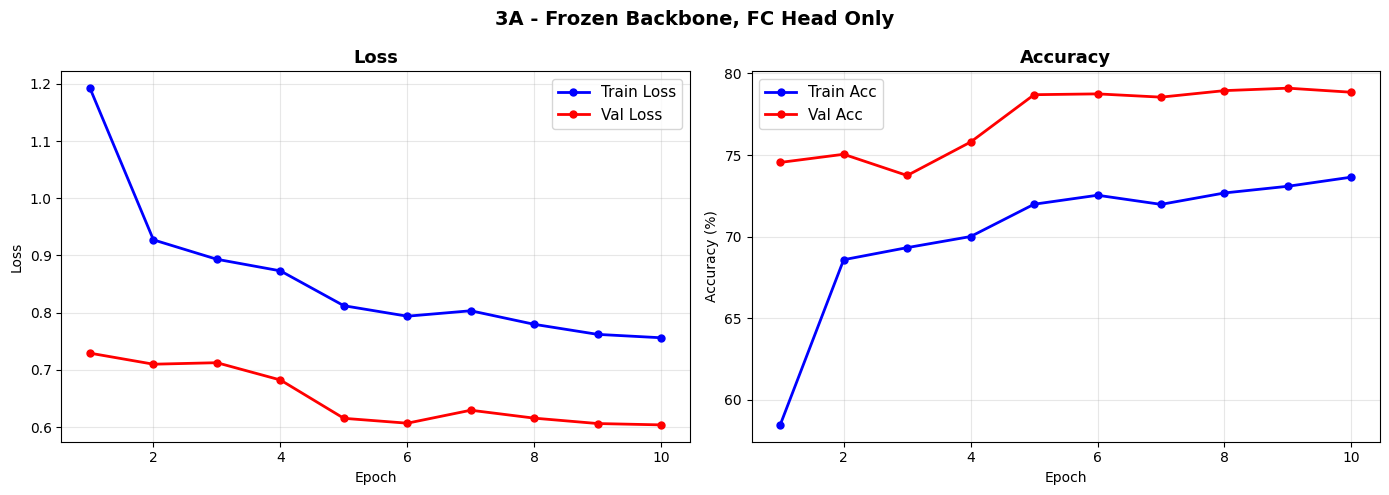


  TL-3A (FC only) - Final Evaluation
  Accuracy      : 79.10%
  Macro Recall  : 79.10%
  Macro F1      : 78.98%

              precision    recall  f1-score   support

    airplane       0.83      0.72      0.77       200
  automobile       0.89      0.89      0.89       200
        bird       0.80      0.77      0.79       200
         cat       0.68      0.60      0.64       200
        deer       0.76      0.72      0.74       200
         dog       0.76      0.82      0.79       200
        frog       0.79      0.86      0.83       200
       horse       0.78      0.82      0.80       200
        ship       0.74      0.88      0.80       200
       truck       0.89      0.82      0.85       200

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



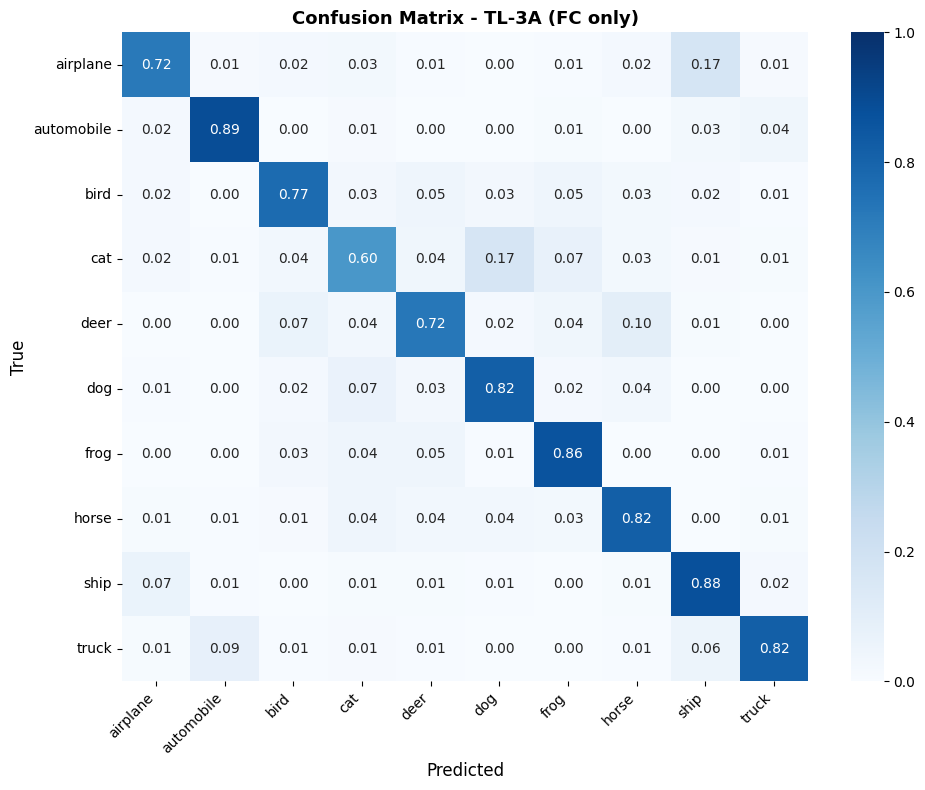

In [17]:
plot_history(history_3a, "3A - Frozen Backbone, FC Head Only")
_, _, preds_3a, labels_3a = evaluate(model_3a, val_loader_pt, crit_3a)
metrics_3a = print_metrics(preds_3a, labels_3a, "TL-3A (FC only)")
plot_confusion(preds_3a, labels_3a, "TL-3A (FC only)")

### 3A Results

Notice how fast it converges. Within the first few epochs the accuracy jumps significantly.
This is because the features are already good - we only need to learn a simple linear mapping
on top of them.

The training and validation curves should stay very close together, meaning almost no overfitting.
With only a few thousand parameters being trained on 12,000 samples, there is not much capacity
to overfit.

The main limitation of 3A is that the feature representation is fixed.
The backbone was not designed for 32x32 images resized to 224x224.
The spatial feature maps it produces may not be perfectly suited to our classes.
Fine-tuning the later layers (3B) should improve this.

### Scenario 3B - Fine-tune the Later Layers

In [18]:
# Scenario 3B: we unfreeze layer3 and layer4 along with the new head.
#
# The decision of where to draw the freezing boundary is based on
# what each part of the network learns:
#
# conv1, layer1 -> very low-level features: edges, color channels, simple gradients.
#                  These are completely universal across all natural images.
#                  There is nothing to gain by modifying them.
#
# layer2        -> low-mid features: simple textures, corners, junctions.
#                  Still fairly universal. We keep these frozen.
#
# layer3        -> mid-high features: parts of objects, complex textures.
#                  These start to be domain-specific. CIFAR-10 might benefit
#                  from slight adaptation here.
#
# layer4        -> high-level features: semantic content, abstract object representations.
#                  This is where ImageNet and CIFAR-10 differ most.
#                  The 1000 ImageNet categories require very different high-level
#                  features than our 10 CIFAR-10 categories.
#
# We use differential learning rates because these are pretrained layers,
# not randomly initialized ones. They already contain useful information.
# A large learning rate would destroy that information before the model
# has a chance to adapt it to our task.

print("Building ResNet18 - Scenario 3B (fine-tune late layers)")
print()
model_3b = build_resnet18(freeze_mode="early").to(DEVICE)

backbone_params = [p for n, p in model_3b.named_parameters()
                   if p.requires_grad and not n.startswith("fc")]
head_params     = [p for n, p in model_3b.named_parameters()
                   if p.requires_grad and n.startswith("fc")]

print(f"Backbone (layer3+layer4) trainable params : {sum(p.numel() for p in backbone_params):,}")
print(f"Head trainable params                     : {sum(p.numel() for p in head_params):,}")

optim_3b = optim.Adam([
    {"params": backbone_params, "lr": 1e-4},  # small lr for pretrained layers
    {"params": head_params,     "lr": 1e-3},  # normal lr for the new head
], weight_decay=1e-4)

crit_3b  = nn.CrossEntropyLoss()
sched_3b = optim.lr_scheduler.CosineAnnealingLR(optim_3b, T_max=EPOCHS_TL)

print()
print("Training 3B...")
print()
history_3b = run_training(
    model_3b, train_loader_pt, val_loader_pt,
    optim_3b, crit_3b, sched_3b,
    epochs=EPOCHS_TL, model_name="TL-3B (fine-tune late layers)"
)

Building ResNet18 - Scenario 3B (fine-tune late layers)

  Freeze mode : early
  Total params: 11,310,410
  Trainable   : 10,627,338  (94.0%)
  Frozen      : 683,072  (6.0%)
Backbone (layer3+layer4) trainable params : 10,493,440
Head trainable params                     : 133,898

Training 3B...

  Epoch   1/10  |  Train Loss: 0.6944  Acc:  76.23%  |  Val Loss: 0.3711  Acc:  87.20% <- best so far
  Epoch   2/10  |  Train Loss: 0.2881  Acc:  90.69%  |  Val Loss: 0.3479  Acc:  88.40% <- best so far
  Epoch   3/10  |  Train Loss: 0.1808  Acc:  94.06%  |  Val Loss: 0.3664  Acc:  88.80% <- best so far
  Epoch   4/10  |  Train Loss: 0.1148  Acc:  96.33%  |  Val Loss: 0.3719  Acc:  88.75%
  Epoch   5/10  |  Train Loss: 0.0817  Acc:  97.22%  |  Val Loss: 0.3399  Acc:  90.15% <- best so far
  Epoch   6/10  |  Train Loss: 0.0482  Acc:  98.61%  |  Val Loss: 0.3605  Acc:  90.35% <- best so far
  Epoch   7/10  |  Train Loss: 0.0341  Acc:  98.91%  |  Val Loss: 0.3361  Acc:  91.40% <- best so far
  E

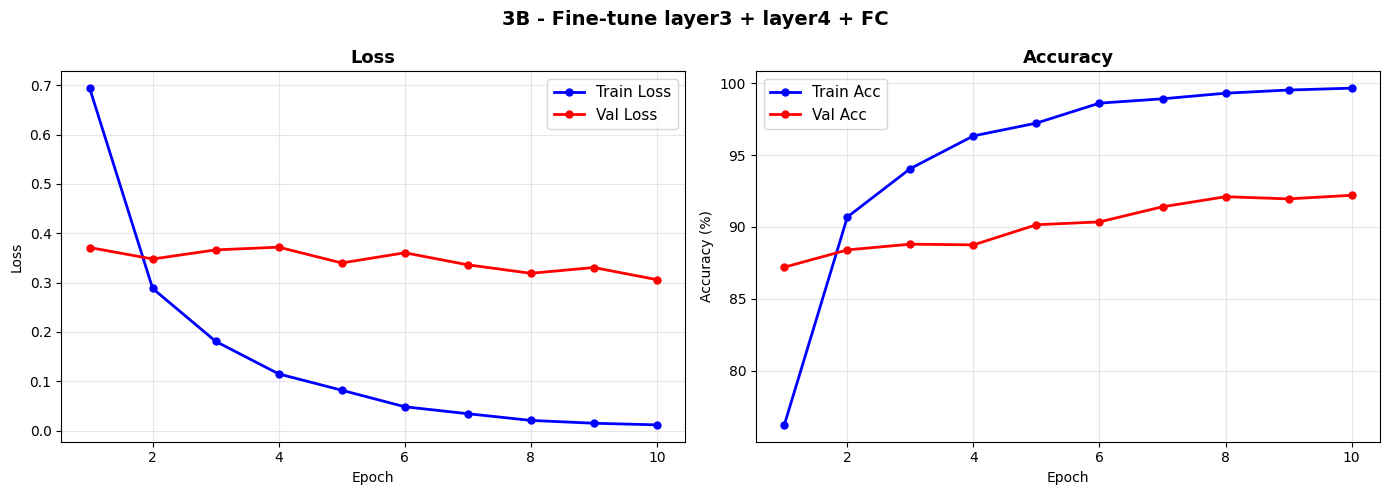


  TL-3B (fine-tune late) - Final Evaluation
  Accuracy      : 92.20%
  Macro Recall  : 92.20%
  Macro F1      : 92.22%

              precision    recall  f1-score   support

    airplane       0.96      0.92      0.94       200
  automobile       0.96      0.96      0.96       200
        bird       0.95      0.90      0.92       200
         cat       0.84      0.81      0.83       200
        deer       0.91      0.95      0.93       200
         dog       0.81      0.88      0.84       200
        frog       0.94      0.94      0.94       200
       horse       0.93      0.93      0.93       200
        ship       0.96      0.97      0.97       200
       truck       0.95      0.95      0.95       200

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



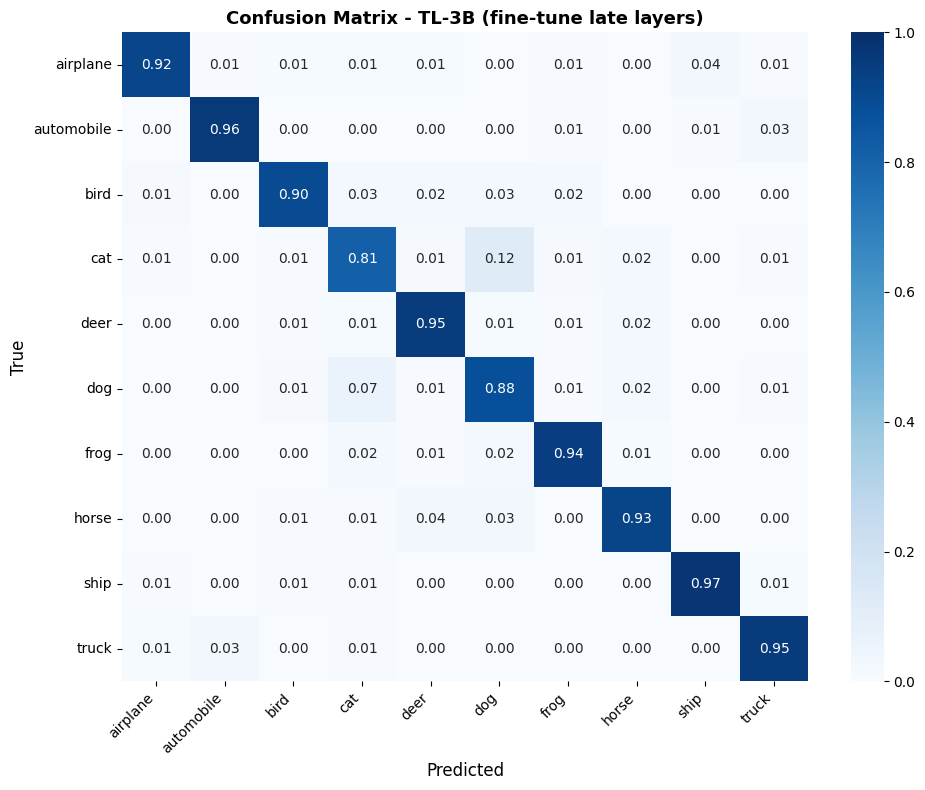

In [19]:
plot_history(history_3b, "3B - Fine-tune layer3 + layer4 + FC")
_, _, preds_3b, labels_3b = evaluate(model_3b, val_loader_pt, crit_3b)
metrics_3b = print_metrics(preds_3b, labels_3b, "TL-3B (fine-tune late)")
plot_confusion(preds_3b, labels_3b, "TL-3B (fine-tune late layers)")

### 3B Results

The accuracy should be higher than 3A.
The improvement came from allowing layer3 and layer4 to adapt their high-level feature
representations to the specific visual concepts in CIFAR-10.

You might also notice that training takes slightly longer per epoch because more
parameters require gradient computation. But the benefit in accuracy is worth it.

The confusion matrix should show improvement on the harder classes like cat and bird.
This is because the high-level feature detectors in layer3 and layer4 can now
specialize for the specific appearance of CIFAR-10 cats and birds rather than
trying to generalize across all 1000 ImageNet categories.

### Scenario 3C - Fine-tune the Entire Model

In [20]:
# Scenario 3C: all parameters are trainable.
#
# This gives the model maximum freedom to adapt every aspect of its
# feature hierarchy to our specific dataset.
#
# The main risk is catastrophic forgetting.
# If the early layers receive gradients with too large a magnitude,
# their carefully learned universal features (edge detectors, color detectors)
# will be overwritten by patterns from our small dataset.
# The model would essentially forget how to see basic visual structure
# and would have to relearn it from 12,000 images, which is not enough.
#
# We prevent this with a four-tier learning rate strategy.
# The earliest layers get a learning rate so small (5e-6) that they
# effectively barely move. The new head gets the highest rate (5e-4).
# Every group in between gets a rate proportional to how much we want it to adapt.
#
# This is the standard approach for full fine-tuning in production systems.

print("Building ResNet18 - Scenario 3C (full fine-tune)")
print()
model_3c = build_resnet18(freeze_mode="none").to(DEVICE)

def get_tiered_param_groups(model):
    def pick(prefixes):
        return [p for n, p in model.named_parameters()
                if any(n.startswith(pr) for pr in prefixes)]
    return [
        {"params": pick(["conv1", "bn1", "layer1"]), "lr": 5e-6},
        # These layers detect edges and simple color patterns.
        # We use an extremely small rate because these features
        # are already perfect and we just do not want to corrupt them.

        {"params": pick(["layer2", "layer3"]),       "lr": 5e-5},
        # These detect textures and mid-level shapes.
        # A slightly larger rate lets them adapt their representations
        # without destroying the fundamental structure.

        {"params": pick(["layer4"]),                 "lr": 1e-4},
        # High-level semantic features. More room to adapt.

        {"params": [p for n, p in model.named_parameters()
                    if n.startswith("fc")],           "lr": 5e-4},
        # Our new classification head. Random initialization means
        # it needs a much larger step size to converge in time.
    ]

optim_3c = optim.Adam(get_tiered_param_groups(model_3c), weight_decay=1e-4)
crit_3c  = nn.CrossEntropyLoss(label_smoothing=0.1)
sched_3c = optim.lr_scheduler.CosineAnnealingLR(optim_3c, T_max=EPOCHS_TL)

print("Training 3C...")
print()
history_3c = run_training(
    model_3c, train_loader_pt, val_loader_pt,
    optim_3c, crit_3c, sched_3c,
    epochs=EPOCHS_TL, model_name="TL-3C (full fine-tune)"
)

Building ResNet18 - Scenario 3C (full fine-tune)

  Freeze mode : none
  Total params: 11,310,410
  Trainable   : 11,310,410  (100.0%)
  Frozen      : 0  (0.0%)
Training 3C...

  Epoch   1/10  |  Train Loss: 1.0512  Acc:  77.96%  |  Val Loss: 0.7988  Acc:  88.70% <- best so far
  Epoch   2/10  |  Train Loss: 0.7359  Acc:  92.43%  |  Val Loss: 0.7734  Acc:  90.55% <- best so far
  Epoch   3/10  |  Train Loss: 0.6523  Acc:  96.18%  |  Val Loss: 0.7443  Acc:  90.95% <- best so far
  Epoch   4/10  |  Train Loss: 0.6059  Acc:  98.04%  |  Val Loss: 0.7139  Acc:  91.65% <- best so far
  Epoch   5/10  |  Train Loss: 0.5765  Acc:  99.01%  |  Val Loss: 0.7089  Acc:  92.20% <- best so far
  Epoch   6/10  |  Train Loss: 0.5563  Acc:  99.68%  |  Val Loss: 0.6895  Acc:  92.90% <- best so far
  Epoch   7/10  |  Train Loss: 0.5496  Acc:  99.68%  |  Val Loss: 0.6825  Acc:  93.30% <- best so far
  Epoch   8/10  |  Train Loss: 0.5403  Acc:  99.82%  |  Val Loss: 0.6822  Acc:  93.05%
  Epoch   9/10  |  Tra

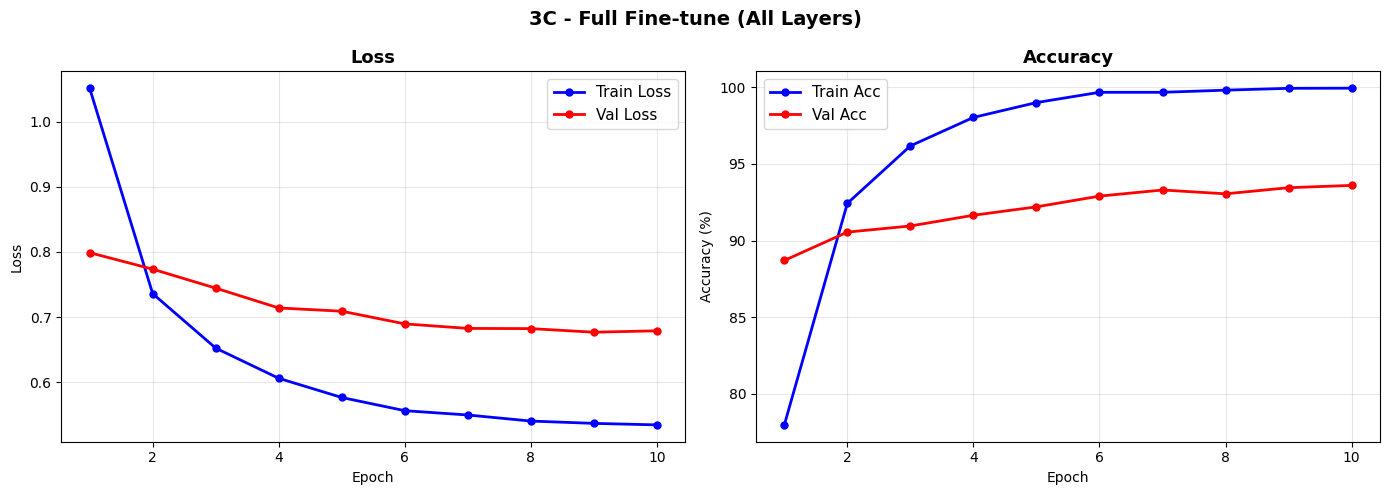


  TL-3C (full fine-tune) - Final Evaluation
  Accuracy      : 93.60%
  Macro Recall  : 93.60%
  Macro F1      : 93.56%

              precision    recall  f1-score   support

    airplane       0.95      0.94      0.95       200
  automobile       0.97      0.97      0.97       200
        bird       0.93      0.94      0.94       200
         cat       0.90      0.81      0.85       200
        deer       0.95      0.94      0.94       200
         dog       0.87      0.92      0.89       200
        frog       0.94      0.98      0.96       200
       horse       0.94      0.94      0.94       200
        ship       0.97      0.95      0.96       200
       truck       0.94      0.97      0.96       200

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



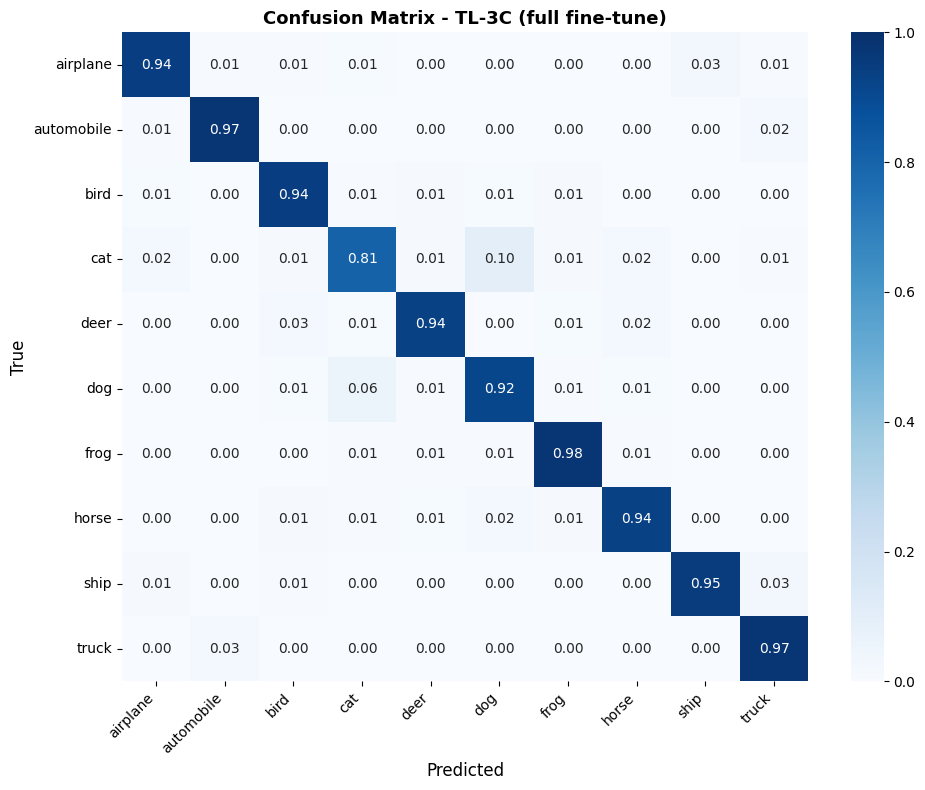

In [21]:
plot_history(history_3c, "3C - Full Fine-tune (All Layers)")
_, _, preds_3c, labels_3c = evaluate(model_3c, val_loader_pt, crit_3c)
metrics_3c = print_metrics(preds_3c, labels_3c, "TL-3C (full fine-tune)")
plot_confusion(preds_3c, labels_3c, "TL-3C (full fine-tune)")

### 3C Results

This scenario should achieve the highest validation accuracy of the three.
The entire network adapts to CIFAR-10 while preserving the foundational knowledge
in early layers through the very small learning rate.

Compare the confusion matrix to 3A. The improvements should be most visible
on the classes that require nuanced high-level discrimination.

One thing to watch for in the loss curves: since all layers are updating,
the training curve may be a bit less smooth than 3A or 3B.
This is normal. More degrees of freedom means a more complex optimization landscape.

It is also worth noting that the performance gap between 3B and 3C is usually
smaller than the gap between 3A and 3B. The early layers genuinely contribute
very little to the difference in final accuracy for this particular task,
which confirms the domain analysis we did at the start: low-level features
from ImageNet are already perfectly suited to CIFAR-10 and do not need to change.

---
## Part 4 - Filter Visualization: Before and After Training

### Why look at filters

Filters are the actual learned parameters of a convolutional layer.
Each filter is a small matrix of numbers. When it slides over an image,
it produces a high output wherever the image patch closely matches the filter pattern
and a low output wherever it does not match.

Visualizing first-layer filters as images is meaningful because the first layer
directly processes raw pixel values. We can interpret the result as a visual pattern
that the filter responds to.

Deeper layer filters cannot be visualized as easily because they process the output
of previous layers rather than raw pixels, and those intermediate representations
have no direct visual interpretation.

### What to look for

For a randomly initialized network you expect to see noise.
The filters are random and respond to nothing in particular.

For a trained network you expect to see structure.
The most common patterns that emerge from training on natural images are:
edge detectors (high response on one side of the filter, low on the other),
color detectors (high response to one or two color channels),
and frequency detectors (patterns of alternating bright and dark bands at various orientations).

These patterns emerge because they are genuinely useful for recognizing the objects
in the dataset. The optimization process discovered them through gradient descent
without us telling it what to look for.

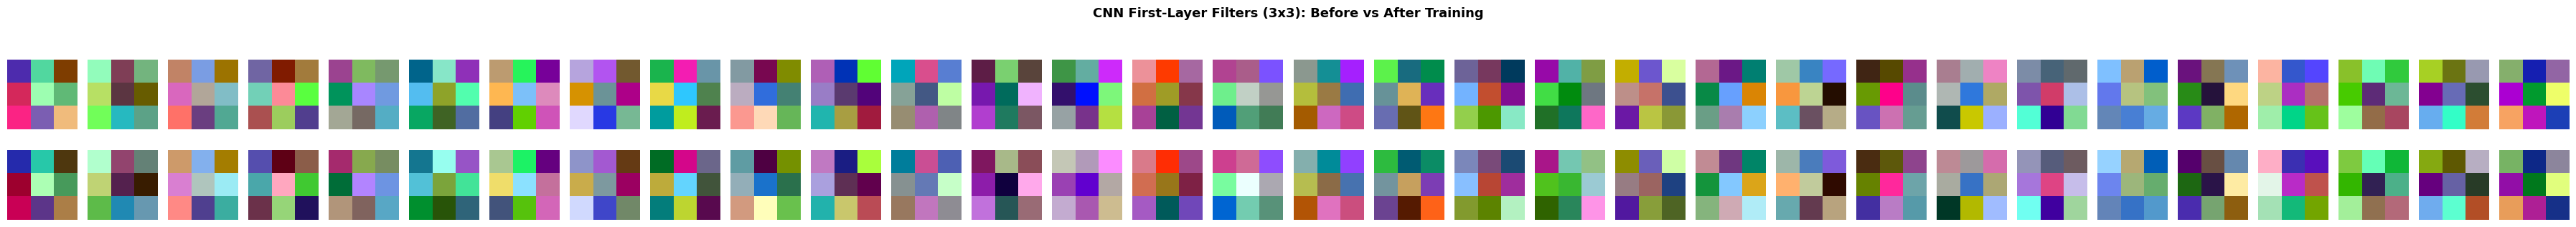

Before training - top row:
  All filters look like colored noise.
  There is no discernible pattern or structure.
  The network responds randomly to everything.

After training - bottom row:
  Filters now show clear visual structure.
  Look for filters where one side is clearly brighter than the other.
  These are edge detectors responding to boundaries between regions.
  Look for filters dominated by one color channel.
  These are color detectors that fire when a specific hue is present.
  Look for filters with a bright center and darker border.
  These are blob detectors responding to small localized bright regions.

The network learned these detectors because they are useful for
distinguishing the 10 classes. An edge detector helps identify the
silhouette of an airplane. A color detector helps distinguish
the greenery around a frog from the blue sky around an airplane.


In [28]:
# CNN filters: side-by-side comparison of before and after training.
# We already captured filters_cnn_before at the start of Part 2.

fig, axes_all = plt.subplots(2, 32, figsize=(36, 3.5))
row_labels = ["Before training (random)", "After training (learned)"]

for row, (filters, label) in enumerate([(filters_cnn_before, row_labels[0]),
                                         (filters_cnn_after,  row_labels[1])]):
    for i in range(32):
        f     = filters[i]
        f_norm = (f - f.min()) / (f.max() - f.min() + 1e-8)
        axes_all[row][i].imshow(f_norm.permute(1,2,0).numpy(), interpolation="nearest")
        axes_all[row][i].axis("off")
    axes_all[row][0].set_ylabel(label, rotation=0, labelpad=130,
                                fontsize=9, fontweight="bold", va="center")

plt.suptitle("CNN First-Layer Filters (3x3): Before vs After Training",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Before training - top row:")
print("  All filters look like colored noise.")
print("  There is no discernible pattern or structure.")
print("  The network responds randomly to everything.")
print()
print("After training - bottom row:")
print("  Filters now show clear visual structure.")
print("  Look for filters where one side is clearly brighter than the other.")
print("  These are edge detectors responding to boundaries between regions.")
print("  Look for filters dominated by one color channel.")
print("  These are color detectors that fire when a specific hue is present.")
print("  Look for filters with a bright center and darker border.")
print("  These are blob detectors responding to small localized bright regions.")
print()
print("The network learned these detectors because they are useful for")
print("distinguishing the 10 classes. An edge detector helps identify the")
print("silhouette of an airplane. A color detector helps distinguish")
print("the greenery around a frog from the blue sky around an airplane.")

ResNet conv1 shape: torch.Size([64, 3, 7, 7])
  64 filters, each 7x7 pixels, operating on 3 input channels



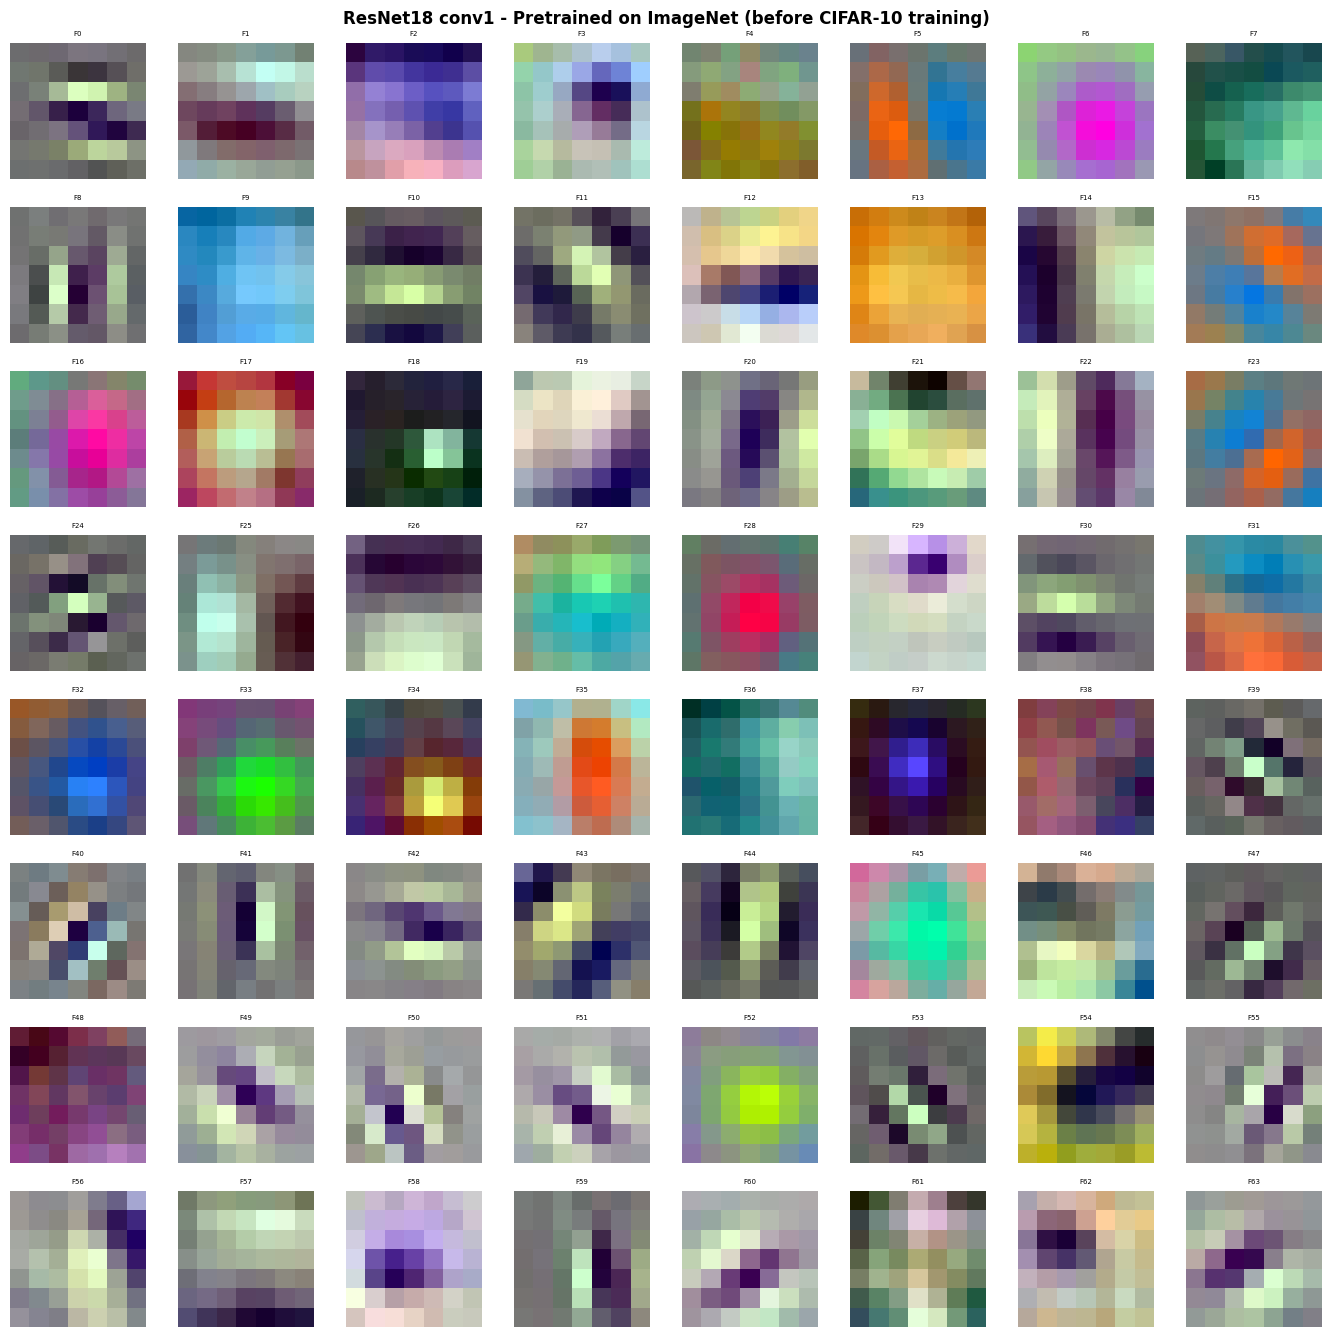

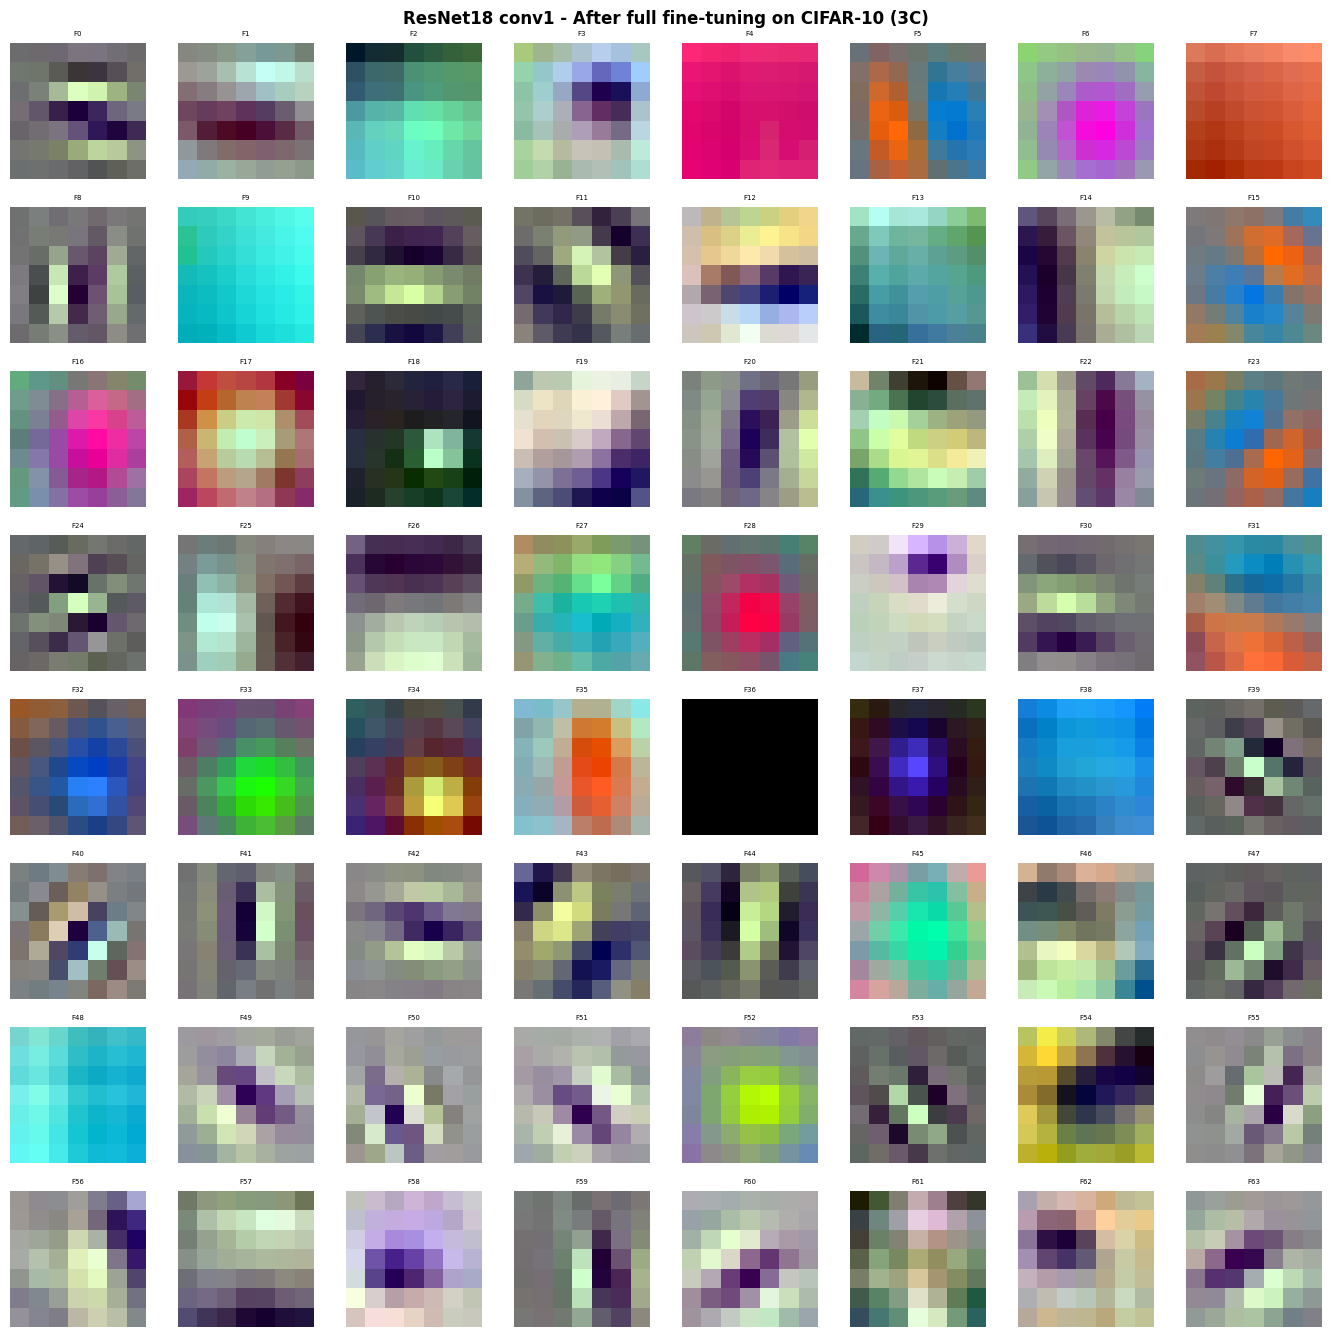

Average absolute change per filter value : 0.000151
Relative change compared to original     : 0.20%

The filters changed by a very small amount despite running 10 epochs of training.
This is exactly what we want. The tiny learning rate (5e-6) for early layers
protected the universal features from being overwritten.

If you compare the two grids visually, the patterns should look nearly identical.
This confirms that low-level visual features (edges, colors, gradients)
are genuinely universal across natural image datasets and do not need to be relearned.


In [29]:
# ResNet18 filters: pretrained on ImageNet vs after fine-tuning on CIFAR-10 (3C).
#
# ResNet's first conv layer uses 7x7 filters instead of our 3x3.
# The larger filter size gives a bigger receptive field in the very first layer,
# which is useful when the network needs to process high-resolution 224x224 images.
# It captures more context in a single operation at the cost of more parameters.

resnet_ref = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
filters_resnet_imagenet  = resnet_ref.conv1.weight.detach().cpu().clone()
filters_resnet_finetuned = model_3c.conv1.weight.detach().cpu().clone()

print(f"ResNet conv1 shape: {filters_resnet_imagenet.shape}")
print(f"  64 filters, each 7x7 pixels, operating on 3 input channels")
print()

plot_filters(filters_resnet_imagenet,
             "ResNet18 conv1 - Pretrained on ImageNet (before CIFAR-10 training)",
             n=64, ncols=8)

plot_filters(filters_resnet_finetuned,
             "ResNet18 conv1 - After full fine-tuning on CIFAR-10 (3C)",
             n=64, ncols=8)

# Measure how much the filters actually changed
delta = (filters_resnet_finetuned - filters_resnet_imagenet).abs().mean().item()
relative = delta / filters_resnet_imagenet.abs().mean().item() * 100
print(f"Average absolute change per filter value : {delta:.6f}")
print(f"Relative change compared to original     : {relative:.2f}%")
print()
print("The filters changed by a very small amount despite running 10 epochs of training.")
print("This is exactly what we want. The tiny learning rate (5e-6) for early layers")
print("protected the universal features from being overwritten.")
print()
print("If you compare the two grids visually, the patterns should look nearly identical.")
print("This confirms that low-level visual features (edges, colors, gradients)")
print("are genuinely universal across natural image datasets and do not need to be relearned.")

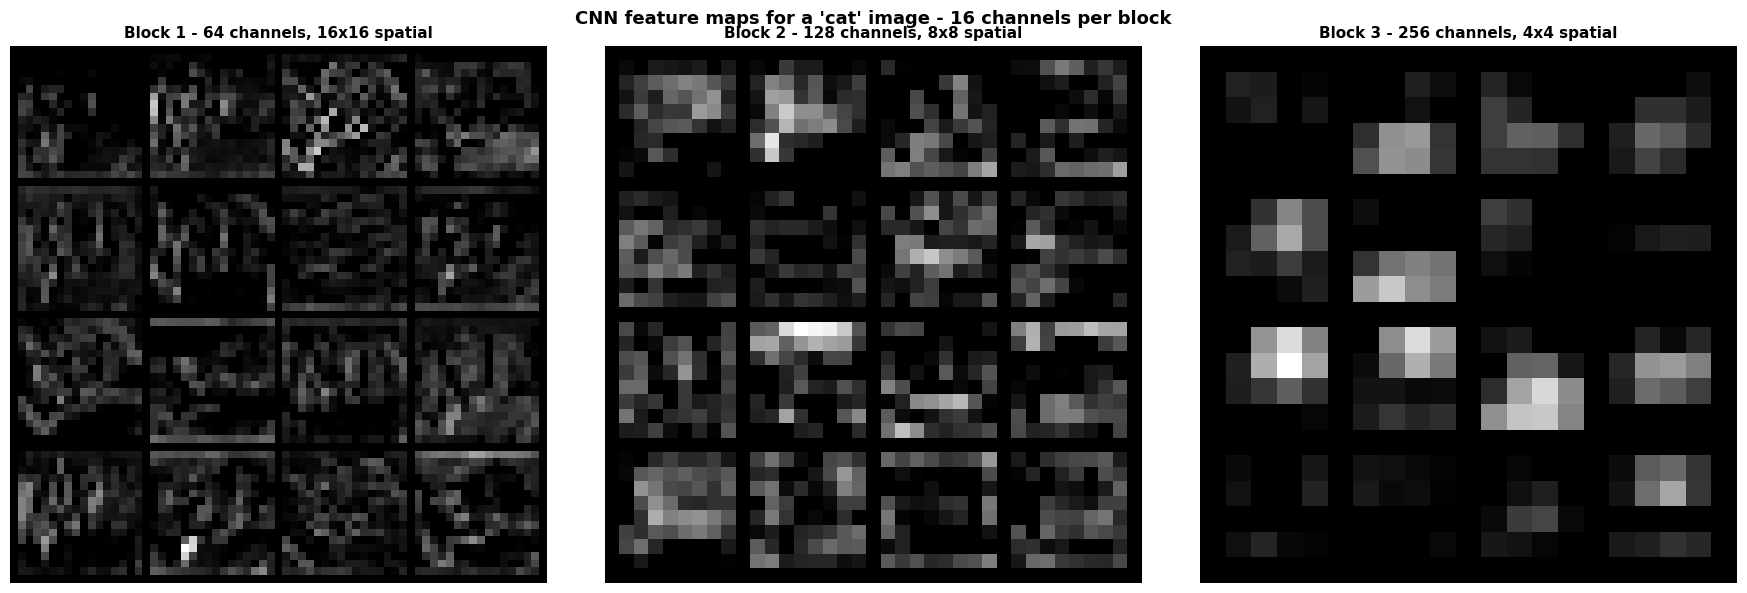

True label: cat

Block 1 (16x16): The feature maps still look somewhat like the original image.
  You can roughly make out the structure of the object.
  Each channel highlights a different local feature like a particular edge direction.

Block 2 (8x8): More abstract. Spatial detail is reduced but strong activations
  appear on the most distinctive parts of the object.

Block 3 (4x4): Very abstract. Only 4x4 spatial positions remain.
  Each cell represents a large region of the original image.
  Strong activations indicate which high-level concepts are present.
  This compressed representation is what the classifier reads.


In [30]:
# Feature map visualization to see what the CNN sees at each depth.
# We use hooks to intercept the output of each conv block during a forward pass.
# A hook is a function that PyTorch calls automatically after a layer computes its output.

sample_img, sample_label = full_val_basic[0]
sample_tensor = sample_img.unsqueeze(0).to(DEVICE)

cnn_model.eval()
activations = {}

def make_hook(name):
    def hook(module, input, output):
        activations[name] = output.detach().cpu()
    return hook

hooks = []
for i, block in enumerate(cnn_model.features):
    hooks.append(block.register_forward_hook(make_hook(f"block_{i+1}")))

with torch.no_grad():
    _ = cnn_model(sample_tensor)

for h in hooks:
    h.remove()

fig, axes_row = plt.subplots(1, 3, figsize=(18, 6))
block_labels = [
    "Block 1 - 64 channels, 16x16 spatial",
    "Block 2 - 128 channels, 8x8 spatial",
    "Block 3 - 256 channels, 4x4 spatial"
]

for ax, (bname, bkey) in zip(axes_row, zip(block_labels, ["block_1","block_2","block_3"])):
    fmaps  = activations[bkey][0]
    n_show = min(16, fmaps.shape[0])
    grid   = torchvision.utils.make_grid(
        fmaps[:n_show].unsqueeze(1), nrow=4, normalize=True, padding=1)
    ax.imshow(grid.permute(1,2,0).numpy(), cmap="viridis")
    ax.set_title(bname, fontsize=11, fontweight="bold")
    ax.axis("off")

plt.suptitle(f"CNN feature maps for a '{CLASSES[sample_label]}' image - 16 channels per block",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"True label: {CLASSES[sample_label]}")
print()
print("Block 1 (16x16): The feature maps still look somewhat like the original image.")
print("  You can roughly make out the structure of the object.")
print("  Each channel highlights a different local feature like a particular edge direction.")
print()
print("Block 2 (8x8): More abstract. Spatial detail is reduced but strong activations")
print("  appear on the most distinctive parts of the object.")
print()
print("Block 3 (4x4): Very abstract. Only 4x4 spatial positions remain.")
print("  Each cell represents a large region of the original image.")
print("  Strong activations indicate which high-level concepts are present.")
print("  This compressed representation is what the classifier reads.")

---
## Final Comparison - All Models

In [31]:
all_results = {
    "MLP":             {**mlp_metrics,  "best_val_acc": mlp_history["best_val_acc"],
                        "trainable_params": sum(p.numel() for p in MLP().parameters())},
    "CNN":             {**cnn_metrics,  "best_val_acc": cnn_history["best_val_acc"],
                        "trainable_params": sum(p.numel() for p in CNN().parameters())},
    "TL-3A (FC only)": {**metrics_3a,  "best_val_acc": history_3a["best_val_acc"],
                        "trainable_params": sum(p.numel() for p in model_3a.parameters() if p.requires_grad)},
    "TL-3B (Late ft)": {**metrics_3b,  "best_val_acc": history_3b["best_val_acc"],
                        "trainable_params": sum(p.numel() for p in model_3b.parameters() if p.requires_grad)},
    "TL-3C (Full ft)": {**metrics_3c,  "best_val_acc": history_3c["best_val_acc"],
                        "trainable_params": sum(p.numel() for p in model_3c.parameters() if p.requires_grad)},
}

print(f"{'Model':<20}  {'Val Acc':>8}  {'Recall':>8}  {'F1':>8}  {'Trainable Params':>18}")
print("-" * 72)
for name, m in all_results.items():
    print(f"{name:<20}  {m['accuracy']*100:>7.2f}%  {m['macro_recall']*100:>7.2f}%  "
          f"{m['macro_f1']*100:>7.2f}%  {m['trainable_params']:>18,}")

# Save results to a JSON file so they can be referenced later
export = {k: {kk: float(vv) for kk, vv in v.items()} for k, v in all_results.items()}
with open("results_summary.json", "w") as f:
    json.dump(export, f, indent=2)
print()
print("Results saved to results_summary.json")

Model                  Val Acc    Recall        F1    Trainable Params
------------------------------------------------------------------------
MLP                     48.20%    48.20%    47.33%           3,809,034
CNN                     75.35%    75.35%    74.97%           1,180,490
TL-3A (FC only)         79.10%    79.10%    78.98%             133,898
TL-3B (Late ft)         92.20%    92.20%    92.22%          10,627,338
TL-3C (Full ft)         93.60%    93.60%    93.56%          11,310,410

Results saved to results_summary.json


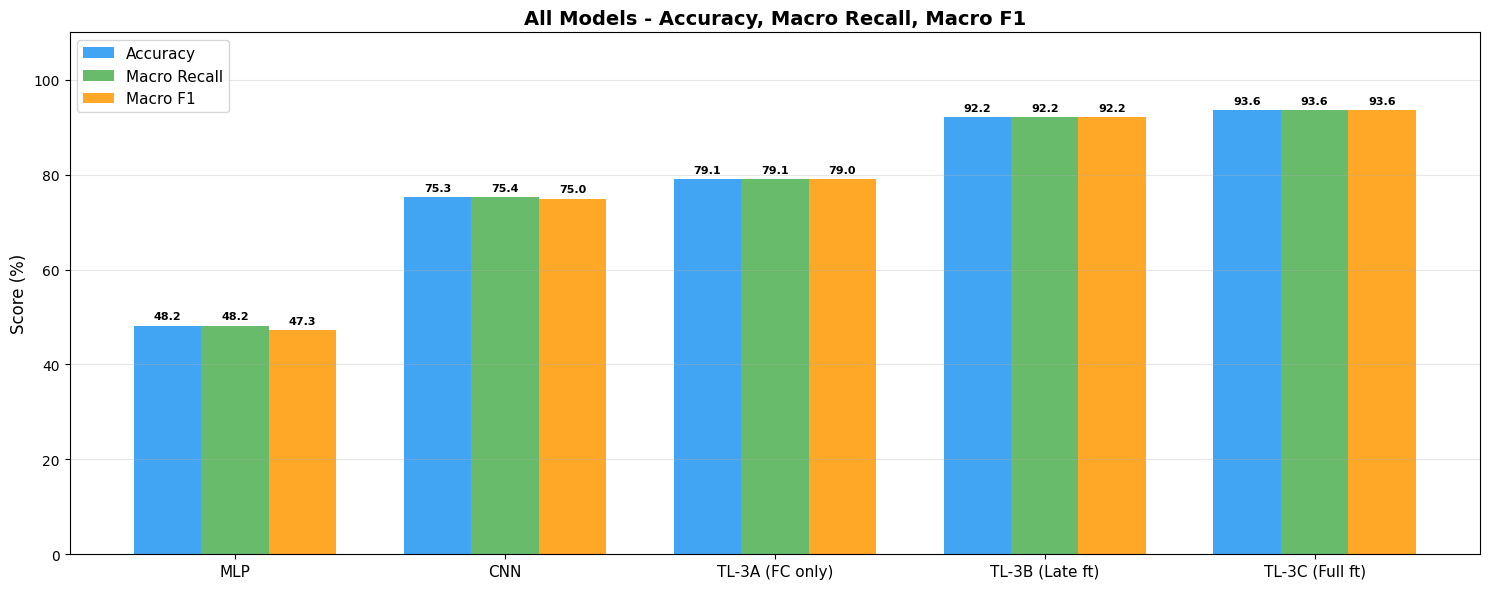

In [32]:
# Grouped bar chart comparing accuracy, recall, and F1 across all models.
names   = list(all_results.keys())
accs    = [v["accuracy"]*100     for v in all_results.values()]
recalls = [v["macro_recall"]*100 for v in all_results.values()]
f1s     = [v["macro_f1"]*100     for v in all_results.values()]

x, w = np.arange(len(names)), 0.25
fig, ax = plt.subplots(figsize=(15, 6))

b1 = ax.bar(x - w, accs,    w, label="Accuracy",     color="#2196F3", alpha=0.85)
b2 = ax.bar(x,     recalls, w, label="Macro Recall", color="#4CAF50", alpha=0.85)
b3 = ax.bar(x + w, f1s,     w, label="Macro F1",     color="#FF9800", alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.annotate(f"{bar.get_height():.1f}",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("All Models - Accuracy, Macro Recall, Macro F1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, 110)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

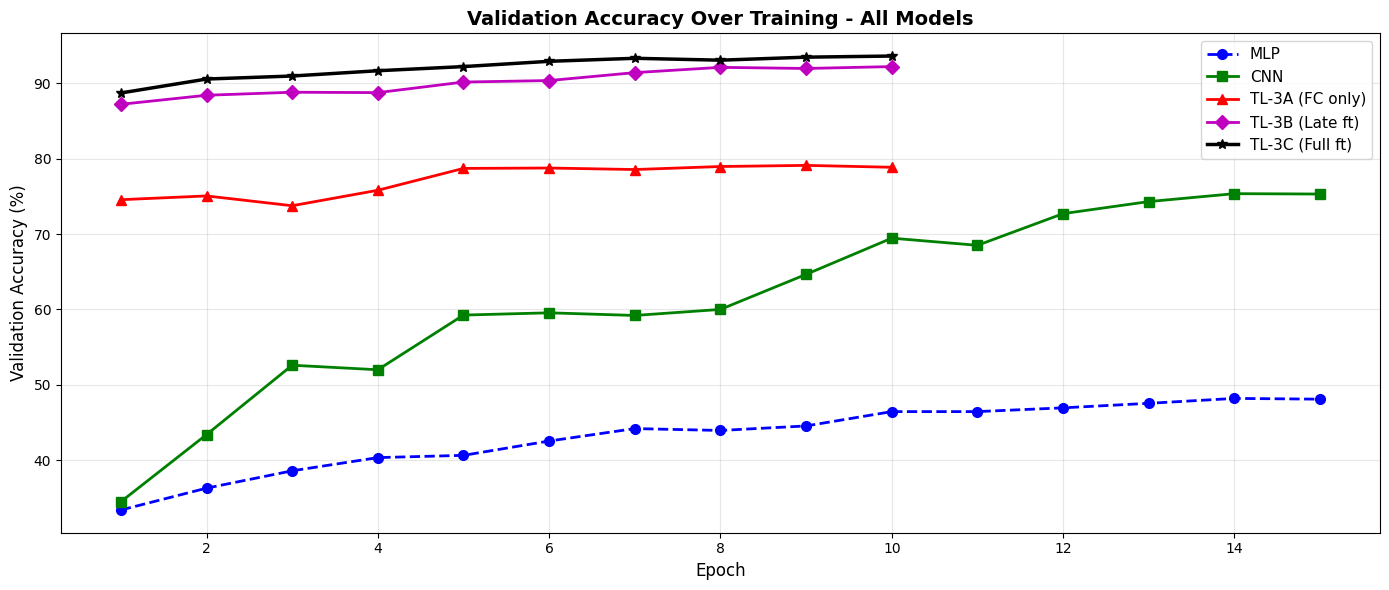

Notice the convergence speed difference between the models.
Transfer learning models (3A, 3B, 3C) start at a much higher accuracy
from the first epoch because the backbone already understands images.
MLP and CNN start near random (10%) and climb slowly.


In [33]:
# Validation accuracy over training epochs for all models.
# This view shows not just the final number but how each model learned.

fig, ax = plt.subplots(figsize=(14, 6))

curves = [
    (mlp_history,  "MLP",             "b--", "o",  2.0),
    (cnn_history,  "CNN",             "g-",  "s",  2.0),
    (history_3a,   "TL-3A (FC only)", "r-",  "^",  2.0),
    (history_3b,   "TL-3B (Late ft)", "m-",  "D",  2.0),
    (history_3c,   "TL-3C (Full ft)", "k-",  "*",  2.5),
]

for h, name, style, marker, lw in curves:
    ep = range(1, len(h["val_acc"]) + 1)
    ax.plot(ep, [a*100 for a in h["val_acc"]],
            style, marker=marker, ms=7, label=name, linewidth=lw)

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax.set_title("Validation Accuracy Over Training - All Models", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice the convergence speed difference between the models.")
print("Transfer learning models (3A, 3B, 3C) start at a much higher accuracy")
print("from the first epoch because the backbone already understands images.")
print("MLP and CNN start near random (10%) and climb slowly.")